# Modélisation

## Objectif de la modélisation

À l'issue des étapes d'exploration, de visualisation et de prétraitement des données, le jeu de données est désormais prêt à être exploité dans le cadre de la phase de modélisation.

L'objectif de cette étape est de construire un ou plusieurs modèles de régression capables de prédire les émissions de dioxyde de carbone (CO₂) des véhicules à partir de leurs caractéristiques techniques et énergétiques.

Plusieurs modèles de régression seront entraînés puis comparés afin d'identifier celui offrant les meilleures performances prédictives. L'évaluation reposera principalement sur les métriques MAE (Mean Absolute Error), RMSE (Root Mean Squared Error) et R² (coefficient de détermination). La MAPE (Mean Absolute Percentage Error) pourra également être utilisée à titre complémentaire.

Conformément aux objectifs du projet, une attention particulière sera portée aux performances des modèles. Leur interprétabilité sera également prise en compte afin de faciliter l'analyse des résultats et la compréhension de l'influence des variables explicatives sur les émissions de CO₂.

In [3]:
# Import des bibliothèques

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.model_selection import learning_curve

from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

## Chargement des jeux de données prétraités

Les jeux de données préparés lors de la phase de prétraitement sont chargés afin d'être utilisés pour l'entraînement et l'évaluation des différents modèles de régression.

In [4]:
# Import des bibliothèques

import pandas as pd
import numpy as np

# Chargement des jeux de données

X_train = pd.read_csv("../data/X_train_final.csv")
X_test = pd.read_csv("../data/X_test_final.csv")

y_train = pd.read_csv("../data/y_train.csv")["co2"]
y_test = pd.read_csv("../data/y_test.csv")["co2"]

## Vérification des jeux de données

Avant de débuter l'entraînement des modèles, une vérification des dimensions des jeux de données est réalisée afin de s'assurer de leur cohérence.

In [5]:
print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test  :", X_test.shape)

print("Dimensions de y_train :", y_train.shape)
print("Dimensions de y_test  :", y_test.shape)

Dimensions de X_train : (44008, 91)
Dimensions de X_test  : (11002, 91)
Dimensions de y_train : (44008,)
Dimensions de y_test  : (11002,)


In [6]:
X_train.head()

,puiss_max,conso_mixte,co_typ_1,nox,ptcl,masse_ordma_min,masse_ordma_max,lib_mrq_ASTON MARTIN,lib_mrq_AUDI,lib_mrq_BENTLEY,...,typ_boite_nb_rapp_A 9,typ_boite_nb_rapp_D 5,typ_boite_nb_rapp_D 6,typ_boite_nb_rapp_D 7,typ_boite_nb_rapp_M 5,typ_boite_nb_rapp_M 6,typ_boite_nb_rapp_M 7,typ_boite_nb_rapp_S 6,typ_boite_nb_rapp_V .,typ_boite_nb_rapp_V 0
0,100.0,7.5,0.203,0.214,0.001,1976,2739,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,190.0,11.9,0.227,0.030,0.001,2075,2075,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100.0,8.8,0.006,0.211,0.000,2356,2585,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,120.0,7.2,0.046,0.197,0.000,2076,2185,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,125.0,5.2,0.440,0.030,0.001,1380,1380,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Présentation des jeux de données

Les jeux de données utilisés pour la modélisation sont désormais entièrement numériques et prêts à être exploités par les différents algorithmes de Machine Learning.

Le jeu d'entraînement (`X_train`) est utilisé pour apprendre les relations entre les variables explicatives et les émissions de CO₂, tandis que le jeu de test (`X_test`) permet d'évaluer les performances des modèles sur des données jamais vues pendant l'entraînement.

Les variables catégorielles ont été transformées par encodage One-Hot lors de la phase de prétraitement, ce qui permet à l'ensemble des modèles de travailler exclusivement sur des variables numériques.

In [7]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 44008 entries, 0 to 44007
Data columns (total 91 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   puiss_max                        44008 non-null  float64
 1   conso_mixte                      44008 non-null  float64
 2   co_typ_1                         44008 non-null  float64
 3   nox                              44008 non-null  float64
 4   ptcl                             44008 non-null  float64
 5   masse_ordma_min                  44008 non-null  int64  
 6   masse_ordma_max                  44008 non-null  int64  
 7   lib_mrq_ASTON MARTIN             44008 non-null  float64
 8   lib_mrq_AUDI                     44008 non-null  float64
 9   lib_mrq_BENTLEY                  44008 non-null  float64
 10  lib_mrq_BMW                      44008 non-null  float64
 11  lib_mrq_CADILLAC                 44008 non-null  float64
 12  lib_mrq_CHEVROLET            

In [8]:
X_train.describe()

,puiss_max,conso_mixte,co_typ_1,nox,ptcl,masse_ordma_min,masse_ordma_max,lib_mrq_ASTON MARTIN,lib_mrq_AUDI,lib_mrq_BENTLEY,...,typ_boite_nb_rapp_A 9,typ_boite_nb_rapp_D 5,typ_boite_nb_rapp_D 6,typ_boite_nb_rapp_D 7,typ_boite_nb_rapp_M 5,typ_boite_nb_rapp_M 6,typ_boite_nb_rapp_M 7,typ_boite_nb_rapp_S 6,typ_boite_nb_rapp_V .,typ_boite_nb_rapp_V 0
count,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000,...,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000,44008.000000
mean,118.898580,7.765022,0.181001,0.299977,0.000900,2103.603368,2343.286153,0.001409,0.006113,0.000432,...,0.000636,0.001113,0.000500,0.000432,0.018042,0.579213,0.000273,0.000023,0.000045,0.005431
std,44.945937,1.376522,0.144890,0.418767,0.000972,294.011894,423.211581,0.037508,0.077944,0.020774,...,0.025216,0.033350,0.022353,0.020774,0.133105,0.493691,0.016511,0.004767,0.006741,0.073495
min,28.000000,0.600000,0.005000,0.000000,0.000000,825.000000,825.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,100.000000,7.300000,0.061000,0.197000,0.000000,1982.000000,2075.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,120.000000,7.800000,0.137000,0.214000,0.001000,2076.000000,2355.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,120.000000,8.300000,0.296000,0.228000,0.001000,2246.000000,2709.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,585.000000,24.500000,0.968000,1.846000,0.023000,2760.000000,3094.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Vérification finale des jeux de données

Avant d'entraîner les modèles, une dernière vérification est réalisée afin de confirmer l'absence de valeurs manquantes dans les jeux d'entraînement et de test. Cette étape garantit que les données sont prêtes pour la modélisation.

In [9]:
# Vérification finale des valeurs manquantes

print("Nombre total de NaN dans X_train :", X_train.isna().sum().sum())
print("Nombre total de NaN dans X_test  :", X_test.isna().sum().sum())

print("Nombre total de NaN dans y_train :", y_train.isna().sum())
print("Nombre total de NaN dans y_test  :", y_test.isna().sum())

Nombre total de NaN dans X_train : 0
Nombre total de NaN dans X_test  : 0
Nombre total de NaN dans y_train : 0
Nombre total de NaN dans y_test  : 0


## Régression linéaire

La régression linéaire constitue le modèle de référence (baseline) de notre étude. Son principe repose sur l'hypothèse d'une relation linéaire entre les variables explicatives et les émissions de CO₂.

Ce modèle présente plusieurs avantages : il est rapide à entraîner, simple à interpréter et permet d'identifier l'influence des différentes variables sur la variable cible. Il servira de point de comparaison pour évaluer les performances des modèles plus complexes étudiés par la suite.

## Évaluation du modèle

### Entraînement du modèle

In [10]:
# Initialisation du modèle
reg_lin = LinearRegression()

# Entraînement
reg_lin.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](91,)","[-0.01,24.01,-0.96,..., 1.29,-1.22,-0.65]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](91,)","['puiss_max','conso_mixte','co_typ_1',...,'typ_boite_nb_rapp_S 6', 'typ_boite_nb_rapp_V .','typ_boite_nb_rapp_V 0']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-26.25
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,91
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(89)


### Prédictions

In [11]:
y_pred_lin = reg_lin.predict(X_test)

### Performances du modèle

In [12]:
mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)
mape_lin = mean_absolute_percentage_error(y_test, y_pred_lin)

print(f"MAE  : {mae_lin:.2f}")
print(f"RMSE : {rmse_lin:.2f}")
print(f"R²   : {r2_lin:.4f}")
print(f"MAPE : {mape_lin:.4f}")

MAE  : 1.10
RMSE : 1.80
R²   : 0.9973
MAPE : 0.0061


### Comparaison avec un modèle de référence (DummyRegressor)

In [13]:
# Initialisation du DummyRegressor
dummy = DummyRegressor(strategy="mean")

# Entraînement
dummy.fit(X_train, y_train)

# Prédictions
y_pred_dummy = dummy.predict(X_test)

# Évaluation
mae_dummy = mean_absolute_error(y_test, y_pred_dummy)
rmse_dummy = np.sqrt(mean_squared_error(y_test, y_pred_dummy))
r2_dummy = r2_score(y_test, y_pred_dummy)
mape_dummy = mean_absolute_percentage_error(y_test, y_pred_dummy)

print("DummyRegressor")
print(f"MAE  : {mae_dummy:.2f}")
print(f"RMSE : {rmse_dummy:.2f}")
print(f"R²   : {r2_dummy:.4f}")
print(f"MAPE : {mape_dummy:.4f}")

DummyRegressor
MAE  : 22.51
RMSE : 34.40
R²   : -0.0000
MAPE : 0.1310


### Comparaison des performances

| Modèle              |   MAE |  RMSE |      R² |   MAPE |
| ------------------- | ----: | ----: | ------: | -----: |
| DummyRegressor      | 22.51 | 34.40 | -0.0000 | 0.1310 |
| Régression linéaire |  1.10 |  1.80 |  0.9973 | 0.0061 |


Le DummyRegressor constitue un modèle de référence qui prédit systématiquement la moyenne des émissions de CO₂ observées dans le jeu d'entraînement, sans exploiter les variables explicatives.

Les résultats obtenus montrent des performances très limitées (MAE = 22,51 g/km, RMSE = 34,40 g/km, R² ≈ 0), ce qui confirme qu'une prédiction basée uniquement sur la moyenne ne permet pas de représenter correctement les émissions de CO₂.

En comparaison, la régression linéaire réduit considérablement les erreurs de prédiction (MAE = 1,10 g/km, RMSE = 1,80 g/km) et explique 99,73 % de la variabilité des émissions (R² = 0,9973). Cette amélioration très importante émontre que la régression linéaire exploite efficacement les informations contenues dans les variables explicatives pour prédire les émissions de CO₂.

### Analyse de la capacité de généralisation

In [14]:
print("Score R² sur le jeu d'entraînement :", reg_lin.score(X_train, y_train))
print("Score R² sur le jeu de test         :", reg_lin.score(X_test, y_test))

Score R² sur le jeu d'entraînement : 0.9971740170096084
Score R² sur le jeu de test         : 0.9972654606136121



Les coefficients de détermination obtenus sur les jeux d'entraînement (R² = 0,9972) et de test (R² = 0,9973) sont quasiment identiques.

Cette proximité montre que le modèle généralise correctement aux données non vues et ne présente pas de signe de surapprentissage. Les excellentes performances observées sur le jeu de test traduisent une relation fortement linéaire entre les variables explicatives retenues et les émissions de CO₂.

### Valeurs réelles vs valeurs prédites

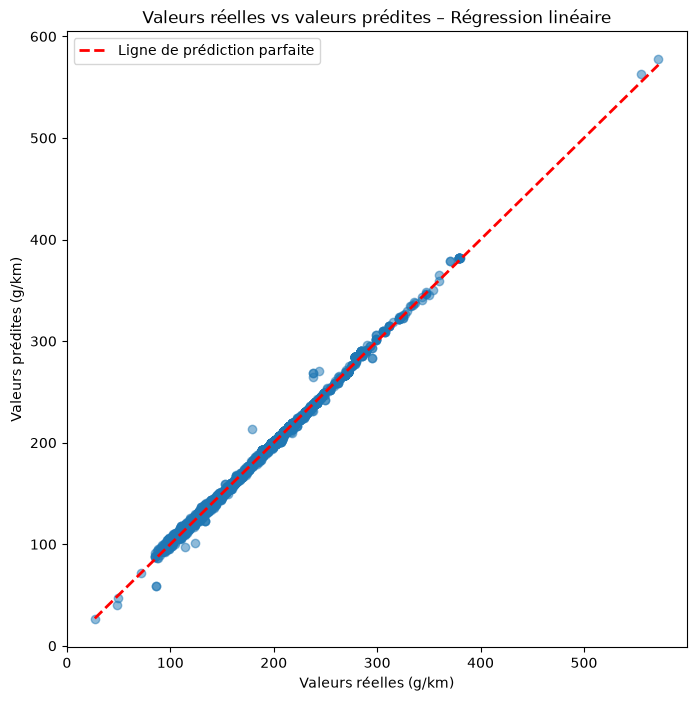

In [15]:
plt.figure(figsize=(8, 8))

# Valeurs réelles vs prédites
plt.scatter(
    y_test,
    y_pred_lin,
    alpha=0.5
)

# Ligne idéale
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2,
    label="Ligne de prédiction parfaite"
)

plt.xlabel("Valeurs réelles (g/km)")
plt.ylabel("Valeurs prédites (g/km)")
plt.title("Valeurs réelles vs valeurs prédites – Régression linéaire")
plt.legend()

plt.show()

La régression linéaire obtient d'excellentes performances sur le jeu de test, avec un coefficient de détermination de 0,9973, indiquant que le modèle explique près de 99,7 % de la variabilité des émissions de CO₂. Les erreurs de prédiction restent très faibles, comme en témoignent le MAE (1,10 g/km), le RMSE (1,80 g/km) et le MAPE (0,61 %).

Le nuage de points met en évidence une très forte concordance entre les valeurs réelles et les valeurs prédites. La grande majorité des observations est alignée le long de la diagonale représentant une prédiction parfaite, ce qui confirme visuellement l'excellente qualité des prédictions.

Quelques écarts sont observés pour un nombre limité de véhicules, principalement pour certaines valeurs élevées des émissions de CO₂. Toutefois, ces écarts restent faibles au regard de l'ensemble des observations et n'affectent pas la qualité globale du modèle.

La comparaison avec le DummyRegressor montre également que la régression linéaire surpasse très largement un modèle naïf prédisant uniquement la moyenne des émissions de CO₂. L'ensemble de ces résultats confirme que le modèle exploite efficacement les informations contenues dans les variables explicatives et constitue une excellente référence (baseline) pour comparer les modèles plus complexes étudiés par la suite.

### Analyse des résidus

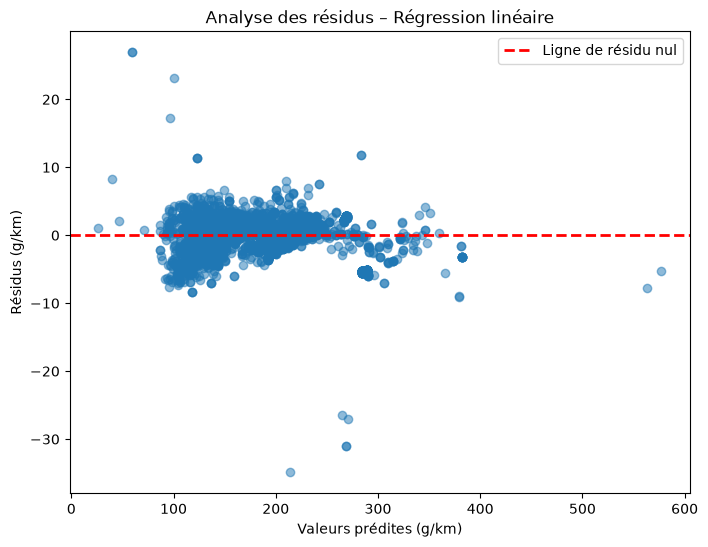

In [16]:
# Calcul des résidus
residus = y_test - y_pred_lin

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_lin,
    residus,
    alpha=0.5
)

# Ligne horizontale représentant un résidu nul
plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Ligne de résidu nul"
)

plt.xlabel("Valeurs prédites (g/km)")
plt.ylabel("Résidus (g/km)")
plt.title("Analyse des résidus – Régression linéaire")
plt.legend()

plt.show()

Le graphique des résidus montre que les erreurs de prédiction sont globalement réparties de manière aléatoire autour de la ligne de résidu nul, sans structure particulière. Cette répartition indique que le modèle ne présente pas de biais systématique et ne surestime ni ne sous-estime les émissions de CO₂.

Quelques observations présentent des résidus plus importants, mais elles restent peu nombreuses au regard de l'ensemble des données. La dispersion des résidus demeure globalement homogène sur l'ensemble des valeurs prédites, ce qui suggère que les hypothèses de la régression linéaire sont raisonnablement respectées.

Cette analyse confirme la bonne qualité d'ajustement du modèle et vient compléter les excellents résultats obtenus avec les métriques d'évaluation (R² = 0,9973, RMSE = 1,80 g/km).

### Courbe d'apprentissage

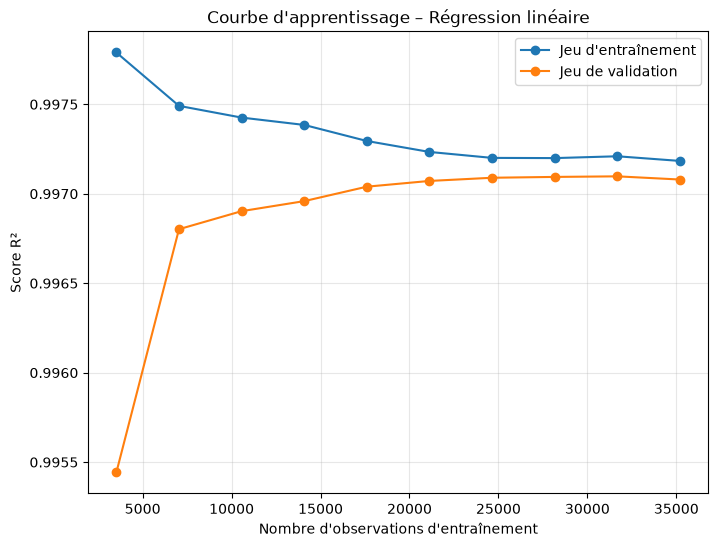

In [17]:
# Calcul des courbes d'apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    estimator=reg_lin,
    X=X_train,
    y=y_train,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Moyennes des scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# Graphique
plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Jeu d'entraînement"
)

plt.plot(
    train_sizes,
    test_mean,
    marker="o",
    label="Jeu de validation"
)

plt.xlabel("Nombre d'observations d'entraînement")
plt.ylabel("Score R²")
plt.title("Courbe d'apprentissage – Régression linéaire")
plt.legend()

plt.grid(alpha=0.3)

plt.show()

La courbe d'apprentissage montre que les scores obtenus sur les jeux d'entraînement et de validation convergent rapidement vers des valeurs très élevées et restent très proches l'un de l'autre tout au long de l'apprentissage.

L'écart très faible entre les deux courbes indique que la régression linéaire généralise correctement aux données non vues et ne présente pas de signe de surapprentissage. Les performances se stabilisent à partir d'environ 20 000 observations, ce qui suggère que le modèle exploite efficacement les informations disponibles et que l'ajout d'un plus grand nombre d'observations n'apporterait qu'un gain marginal de performance.

Cette analyse confirme les excellents résultats observés précédemment avec les différentes métriques d'évaluation ainsi que les graphiques des valeurs prédites et des résidus.

## Régression Ridge

La régression Ridge est une extension de la régression linéaire qui intègre une pénalisation de type L2 sur les coefficients du modèle.

Cette régularisation permet de limiter l'influence des variables fortement corrélées et de réduire le risque de surapprentissage. Elle est particulièrement adaptée lorsque le jeu de données comporte un grand nombre de variables explicatives, comme c'est le cas après l'encodage One-Hot des variables catégorielles.

L'objectif est d'évaluer si cette pénalisation améliore les performances prédictives par rapport à la régression linéaire classique.

### Entraînement du modèle

In [18]:
from sklearn.linear_model import Ridge

# Initialisation du modèle
ridge = Ridge(alpha=1.0)

# Entraînement
ridge.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

### Prédictions

In [19]:
# Prédictions sur le jeu de test
y_pred_ridge = ridge.predict(X_test)

### Performances du modèle

In [20]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)
mape_ridge = mean_absolute_percentage_error(y_test, y_pred_ridge)

print(f"MAE  : {mae_ridge:.2f}")
print(f"RMSE : {rmse_ridge:.2f}")
print(f"R²   : {r2_ridge:.4f}")
print(f"MAPE : {mape_ridge:.4f}")

MAE  : 1.12
RMSE : 1.82
R²   : 0.9972
MAPE : 0.0062


### Comparaison avec le DummyRegressor

In [21]:
comparaison_dummy_ridge = pd.DataFrame({
    "Modèle": ["DummyRegressor", "Ridge"],
    "MAE": [mae_dummy, mae_ridge],
    "RMSE": [rmse_dummy, rmse_ridge],
    "R²": [r2_dummy, r2_ridge],
    "MAPE": [mape_dummy, mape_ridge]
})

comparaison_dummy_ridge = comparaison_dummy_ridge.round(4)
comparaison_dummy_ridge

,Modèle,MAE,RMSE,R²,MAPE
0,DummyRegressor,22.5123,34.3963,-0.0000,0.1310
1,Ridge,1.1243,1.8214,0.9972,0.0062


Le DummyRegressor constitue un modèle de référence qui prédit systématiquement la moyenne des émissions de CO₂ observées dans le jeu d'entraînement, sans exploiter les variables explicatives.

Les performances obtenues avec Ridge sont très largement supérieures à celles du DummyRegressor. Alors que le modèle de référence obtient un coefficient de détermination proche de zéro (R² ≈ 0), Ridge explique 99,72 % de la variabilité des émissions de CO₂ et réduit fortement les erreurs de prédiction (MAE = 1,12 g/km, RMSE = 1,82 g/km).

Cette comparaison confirme que la régularisation L2 permet au modèle d'exploiter efficacement les informations contenues dans les variables explicatives pour prédire les émissions de CO₂.

### Analyse de la capacité de généralisation

In [22]:
print("Score R² sur le jeu d'entraînement :", ridge.score(X_train, y_train))
print("Score R² sur le jeu de test         :", ridge.score(X_test, y_test))

Score R² sur le jeu d'entraînement : 0.997122001184411
Score R² sur le jeu de test         : 0.9971957737332887


La régression Ridge obtient d'excellentes performances sur le jeu de test.

Le coefficient de détermination (R² = 0,9972) montre que le modèle explique près de 99,7 % de la variabilité des émissions de CO₂. Les erreurs de prédiction restent très faibles, avec un MAE de 1,12 g/km, un RMSE de 1,82 g/km et un MAPE de 0,62 %.

Les scores obtenus sur les jeux d'entraînement et de test sont très proches, ce qui indique que le modèle généralise correctement et ne présente pas de signe de surapprentissage.

Toutefois, les performances sont très légèrement inférieures à celles de la régression linéaire. Sur ce jeu de données, l'ajout d'une pénalisation L2 n'apporte donc pas de gain de performance par rapport au modèle linéaire de référence.

### Valeurs réelles vs valeurs prédites

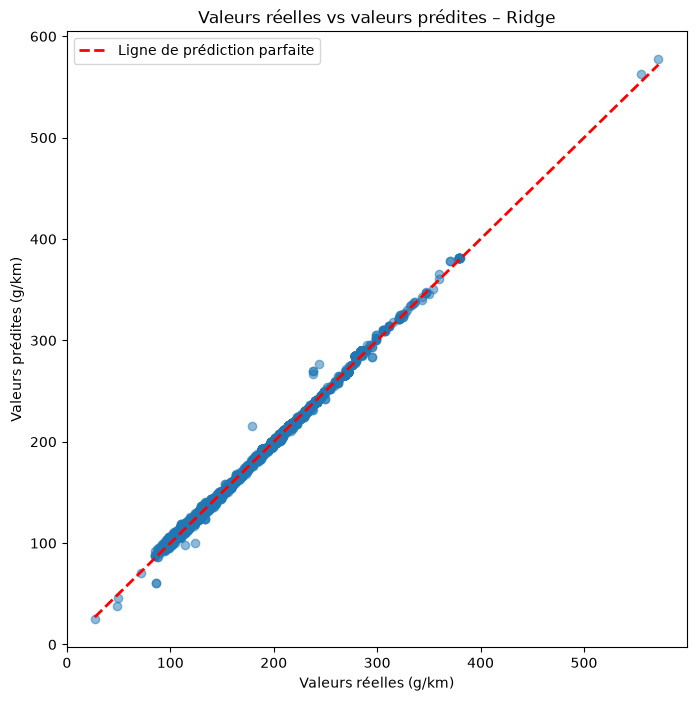

In [23]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    y_pred_ridge,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2,
    label="Ligne de prédiction parfaite"
)

plt.xlabel("Valeurs réelles (g/km)")
plt.ylabel("Valeurs prédites (g/km)")
plt.title("Valeurs réelles vs valeurs prédites – Ridge")
plt.legend()

plt.show()

Le nuage de points met en évidence une très forte concordance entre les valeurs réelles et les valeurs prédites par le modèle Ridge. La quasi-totalité des observations est alignée le long de la diagonale représentant une prédiction parfaite, ce qui traduit une excellente qualité de prédiction.

Quelques écarts sont observés pour un nombre limité de véhicules, principalement pour certaines valeurs élevées des émissions de CO₂. Toutefois, ces écarts restent faibles au regard de l'ensemble des observations et n'affectent pas la qualité globale du modèle.

Cette représentation graphique est cohérente avec les excellentes performances obtenues par le modèle (R² = 0,9972, RMSE = 1,82 g/km) et montre que la régularisation L2 conserve une très bonne capacité de prédiction des émissions de CO₂.

### Analyse des résidus

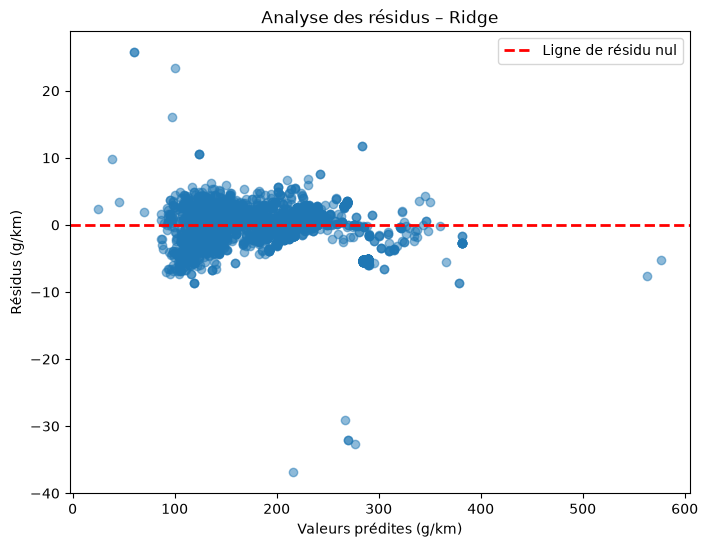

In [24]:
# Calcul des résidus
residus_ridge = y_test - y_pred_ridge

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_ridge,
    residus_ridge,
    alpha=0.5
)

# Ligne horizontale représentant un résidu nul
plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Ligne de résidu nul"
)

plt.xlabel("Valeurs prédites (g/km)")
plt.ylabel("Résidus (g/km)")
plt.title("Analyse des résidus – Ridge")
plt.legend()

plt.show()

Le graphique des résidus montre que les erreurs de prédiction du modèle Ridge sont globalement réparties de manière aléatoire autour de la ligne de résidu nul, sans structure particulière. Cette répartition indique que le modèle ne présente pas de biais systématique et ne surestime ni ne sous-estime les émissions de CO₂.

Quelques observations présentent des résidus plus importants, mais elles restent peu nombreuses au regard de l'ensemble des données. La dispersion des résidus demeure globalement homogène sur l'ensemble des valeurs prédites, ce qui suggère que la régularisation L2 préserve une bonne qualité d'ajustement du modèle.

Cette analyse est cohérente avec les excellentes performances obtenues précédemment (R² = 0,9972, RMSE = 1,82 g/km) et confirme que Ridge généralise correctement aux données de test.

### Courbe d'apprentissage

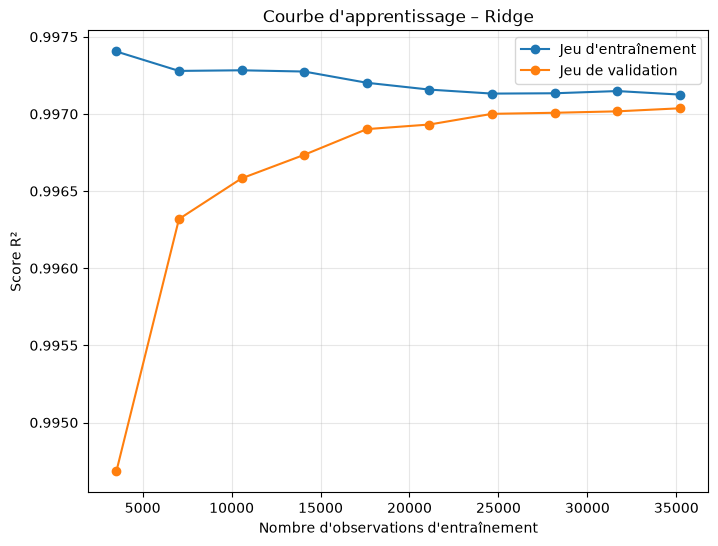

In [25]:

# Calcul des courbes d'apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    estimator=ridge,
    X=X_train,
    y=y_train,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Moyennes des scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# Graphique
plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Jeu d'entraînement"
)

plt.plot(
    train_sizes,
    test_mean,
    marker="o",
    label="Jeu de validation"
)

plt.xlabel("Nombre d'observations d'entraînement")
plt.ylabel("Score R²")
plt.title("Courbe d'apprentissage – Ridge")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

La courbe d'apprentissage montre que les scores obtenus sur les jeux d'entraînement et de validation convergent rapidement vers des valeurs très élevées et restent très proches l'un de l'autre tout au long de l'apprentissage.

L'écart très faible entre les deux courbes indique que le modèle Ridge généralise correctement aux données non vues et ne présente pas de signe de surapprentissage. Les performances se stabilisent à partir d'environ 20 000 observations, ce qui suggère que le modèle exploite efficacement les informations disponibles et que l'ajout d'un plus grand nombre d'observations n'apporterait qu'un gain marginal de performance.

Cette analyse confirme les excellentes performances observées avec les métriques d'évaluation ainsi que les graphiques des valeurs prédites et des résidus.

## Régression Lasso

La régression Lasso est une variante de la régression linéaire qui applique une pénalisation de type L1 sur les coefficients du modèle.

Contrairement à la régression Ridge, cette pénalisation peut réduire certains coefficients exactement à zéro, réalisant ainsi une sélection automatique des variables les moins pertinentes. Cette propriété permet d'obtenir des modèles plus simples et potentiellement plus interprétables.

L'objectif est d'évaluer si cette régularisation améliore les performances prédictives tout en simplifiant le modèle.

### Entraînement du modèle

In [26]:
from sklearn.linear_model import Lasso

# Initialisation du modèle
lasso = Lasso(alpha=1.0)

# Entraînement
lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


### Prédictions

In [27]:
# Prédictions sur le jeu de test
y_pred_lasso = lasso.predict(X_test)

### Performances du modèle

In [28]:
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)
mape_lasso = mean_absolute_percentage_error(y_test, y_pred_lasso)

print(f"MAE  : {mae_lasso:.2f}")
print(f"RMSE : {rmse_lasso:.2f}")
print(f"R²   : {r2_lasso:.4f}")
print(f"MAPE : {mape_lasso:.4f}")

MAE  : 3.94
RMSE : 5.65
R²   : 0.9730
MAPE : 0.0206


### Comparaison avec le DummyRegressor

In [29]:
comparaison_dummy_lasso = pd.DataFrame({
    "Modèle": ["DummyRegressor", "Lasso"],
    "MAE": [mae_dummy, mae_lasso],
    "RMSE": [rmse_dummy, rmse_lasso],
    "R²": [r2_dummy, r2_lasso],
    "MAPE": [mape_dummy, mape_lasso]
})

comparaison_dummy_lasso = comparaison_dummy_lasso.round(4)
comparaison_dummy_lasso

,Modèle,MAE,RMSE,R²,MAPE
0,DummyRegressor,22.5123,34.3963,-0.000,0.1310
1,Lasso,3.9410,5.6517,0.973,0.0206


Le DummyRegressor constitue un modèle de référence qui prédit systématiquement la moyenne des émissions de CO₂ observées dans le jeu d'entraînement, sans exploiter les variables explicatives.

Les performances obtenues avec Lasso sont très largement supérieures à celles du DummyRegressor. Alors que le modèle de référence obtient un coefficient de détermination proche de zéro (R² ≈ 0), Lasso explique 97,30 % de la variabilité des émissions de CO₂ et réduit fortement les erreurs de prédiction (MAE = 3,94 g/km, RMSE = 5,65 g/km).

En revanche, les performances de Lasso restent légèrement inférieures à celles de la régression linéaire et de Ridge. Ce résultat est cohérent avec le principe de la régularisation L1, qui simplifie le modèle en annulant certains coefficients afin de réaliser une sélection automatique des variables. Cette simplification améliore l'interprétabilité du modèle, mais s'accompagne ici d'une légère perte de précision.

### Analyse de la capacité de généralisation

In [30]:
print("Score R² sur le jeu d'entraînement :", lasso.score(X_train, y_train))
print("Score R² sur le jeu de test         :", lasso.score(X_test, y_test))

Score R² sur le jeu d'entraînement : 0.9710453407833566
Score R² sur le jeu de test         : 0.9730017073624333


La régression Lasso obtient de bonnes performances sur le jeu de test, mais celles-ci sont sensiblement inférieures à celles de la régression linéaire et de la régression Ridge.

Le coefficient de détermination (R² = 0,9730) montre que le modèle explique environ 97,3 % de la variabilité des émissions de CO₂. Les erreurs de prédiction restent limitées, avec un MAE de 3,94 g/km, un RMSE de 5,65 g/km et un MAPE de 2,06 %.

Les scores obtenus sur les jeux d'entraînement et de test sont très proches, ce qui indique que le modèle généralise correctement et ne présente pas de signe de surapprentissage.

Toutefois, la pénalisation L1 appliquée par le Lasso réduit fortement l'influence de certaines variables explicatives. Sur ce jeu de données, cette simplification entraîne une diminution des performances prédictives par rapport aux modèles de régression linéaire et Ridge.

### Valeurs réelles vs valeurs prédites

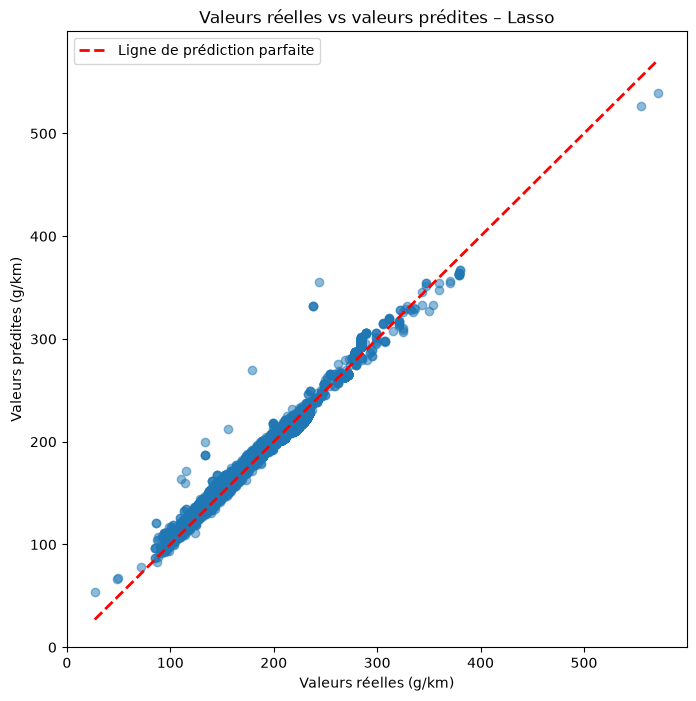

In [31]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred_lasso,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2,
    label="Ligne de prédiction parfaite"
)

plt.xlabel("Valeurs réelles (g/km)")
plt.ylabel("Valeurs prédites (g/km)")
plt.title("Valeurs réelles vs valeurs prédites – Lasso")

plt.legend()

plt.show()

Le nuage de points met en évidence une bonne concordance entre les valeurs réelles et les valeurs prédites par le modèle Lasso. La majorité des observations reste proche de la diagonale représentant une prédiction parfaite, ce qui confirme que le modèle conserve une bonne capacité de prédiction.

Toutefois, la dispersion des points est plus importante que pour la régression linéaire et Ridge. Les écarts à la diagonale sont plus nombreux, notamment pour certaines valeurs intermédiaires et pour les émissions les plus élevées, qui ont tendance à être légèrement sous-estimées.

Cette représentation graphique est cohérente avec les performances du modèle (R² = 0,9730, RMSE = 5,65 g/km) et illustre le compromis introduit par la régularisation L1 : une simplification du modèle grâce à la sélection automatique de variables, au prix d'une légère perte de précision.

### Analyse des résidus

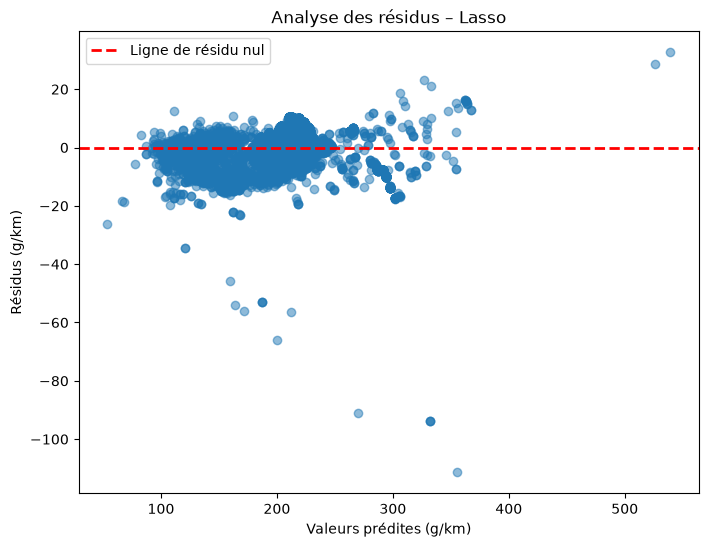

In [32]:
# Calcul des résidus
residus_lasso = y_test - y_pred_lasso

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_lasso,
    residus_lasso,
    alpha=0.5
)

# Ligne de résidu nul
plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Ligne de résidu nul"
)

plt.xlabel("Valeurs prédites (g/km)")
plt.ylabel("Résidus (g/km)")
plt.title("Analyse des résidus – Lasso")

plt.legend()

plt.show()

Le graphique des résidus montre que les erreurs de prédiction du modèle Lasso restent globalement réparties autour de la ligne de résidu nul, ce qui indique l'absence de biais systématique dans les prédictions.

Toutefois, la dispersion des résidus est plus importante que pour la régression linéaire et Ridge. Plusieurs observations présentent des erreurs de prédiction élevées, en particulier pour certaines valeurs intermédiaires et élevées des émissions de CO₂. Cette variabilité plus importante traduit une diminution de la précision du modèle.

Cette analyse est cohérente avec les performances obtenues précédemment (R² = 0,9730, RMSE = 5,65 g/km) et illustre le compromis introduit par la régularisation L1 : en simplifiant le modèle par la sélection automatique de variables, Lasso améliore l'interprétabilité mais au prix d'une augmentation des erreurs de prédiction.

### Courbe d'apprentissage

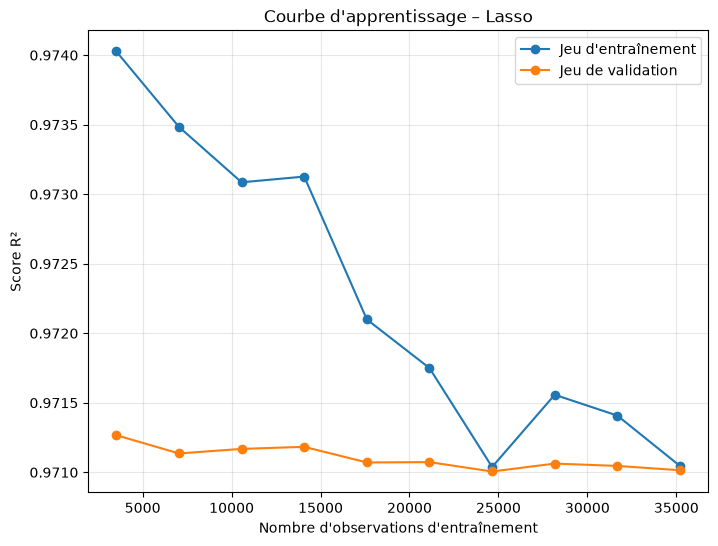

In [33]:
# Calcul des courbes d'apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    estimator=lasso,
    X=X_train,
    y=y_train,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Moyenne des scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# Graphique
plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Jeu d'entraînement"
)

plt.plot(
    train_sizes,
    test_mean,
    marker="o",
    label="Jeu de validation"
)

plt.xlabel("Nombre d'observations d'entraînement")
plt.ylabel("Score R²")
plt.title("Courbe d'apprentissage – Lasso")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

La courbe d'apprentissage montre que les scores obtenus sur les jeux d'entraînement et de validation convergent rapidement et restent très proches tout au long de l'apprentissage.

L'écart très faible entre les deux courbes indique que le modèle Lasso généralise correctement aux données non vues et ne présente pas de signe de surapprentissage. Les performances se stabilisent à partir d'environ 20 000 observations, ce qui suggère que le modèle a atteint son niveau maximal de performance.

En revanche, les deux courbes se stabilisent à un niveau inférieur à celui observé pour la régression linéaire et Ridge. Ce résultat est cohérent avec le principe de la régularisation L1, qui simplifie le modèle en sélectionnant automatiquement les variables les plus pertinentes, au prix d'une légère diminution de la précision des prédictions.

## Arbre de décision

L'arbre de décision est un modèle non linéaire capable de capturer des relations complexes entre les variables explicatives et la variable cible.

Contrairement aux modèles de régression linéaire, Ridge et Lasso, il ne suppose aucune relation linéaire entre les variables. Il segmente progressivement les données en fonction des variables les plus discriminantes afin de minimiser l'erreur de prédiction.

L'objectif est d'évaluer si cette approche permet d'améliorer les performances prédictives par rapport aux modèles linéaires.

### Entraînement du modèle

In [34]:
from sklearn.tree import DecisionTreeRegressor

# Initialisation du modèle
tree = DecisionTreeRegressor(random_state=42)

# Entraînement
tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

### Prédictions

In [35]:
# Prédictions sur le jeu de test
y_pred_tree = tree.predict(X_test)

### Performances du modèle

In [36]:
mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)
mape_tree = mean_absolute_percentage_error(y_test, y_pred_tree)

print(f"MAE  : {mae_tree:.2f}")
print(f"RMSE : {rmse_tree:.2f}")
print(f"R²   : {r2_tree:.4f}")
print(f"MAPE : {mape_tree:.4f}")

MAE  : 0.09
RMSE : 1.43
R²   : 0.9983
MAPE : 0.0006


### Comparaison avec le DummyRegressor

In [37]:
comparaison_dummy_tree = pd.DataFrame({
    "Modèle": ["DummyRegressor", "Arbre de décision"],
    "MAE": [mae_dummy, mae_tree],
    "RMSE": [rmse_dummy, rmse_tree],
    "R²": [r2_dummy, r2_tree],
    "MAPE": [mape_dummy, mape_tree]
})

comparaison_dummy_tree = comparaison_dummy_tree.round(4)
comparaison_dummy_tree

,Modèle,MAE,RMSE,R²,MAPE
0,DummyRegressor,22.5123,34.3963,-0.0000,0.1310
1,Arbre de décision,0.0881,1.4307,0.9983,0.0006


Le DummyRegressor constitue un modèle de référence qui prédit systématiquement la moyenne des émissions de CO₂ observées dans le jeu d'entraînement, sans exploiter les variables explicatives.

Les performances obtenues par l'Arbre de décision sont très largement supérieures à celles du DummyRegressor. Le modèle explique 99,83 % de la variabilité des émissions de CO₂ et réduit considérablement les erreurs de prédiction (MAE = 0,09 g/km, RMSE = 1,43 g/km), ce qui confirme sa très forte capacité à modéliser les relations entre les caractéristiques des véhicules et leurs émissions.

Cette comparaison met en évidence que l'Arbre de décision est le modèle le plus performant parmi ceux évalués dans cette étude. Toutefois, les excellentes performances observées devront être confirmées par l'analyse des résidus et de la courbe d'apprentissage afin de vérifier l'absence de surapprentissage.

### Analyse de la capacité de généralisation

In [38]:
print("Score R² sur le jeu d'entraînement :", tree.score(X_train, y_train))
print("Score R² sur le jeu de test         :", tree.score(X_test, y_test))

Score R² sur le jeu d'entraînement : 0.9999900108260182
Score R² sur le jeu de test         : 0.9982698295518875


L'arbre de décision obtient les meilleures performances parmi les modèles évalués.

Le coefficient de détermination (R² = 0,9983) montre que le modèle explique plus de 99,8 % de la variabilité des émissions de CO₂. Les erreurs de prédiction sont les plus faibles de cette étude, avec un MAE de 0,09 g/km, un RMSE de 1,43 g/km et un MAPE de 0,06 %.

Les scores obtenus sur les jeux d'entraînement (R² = 0,99999) et de test (R² = 0,99827) restent très élevés, bien qu'un léger écart apparaisse entre les deux. Cela indique un faible début de surapprentissage, phénomène classique pour un arbre de décision non élagué, sans pour autant dégrader significativement les performances sur le jeu de test.

### Valeurs réelles vs valeurs prédites

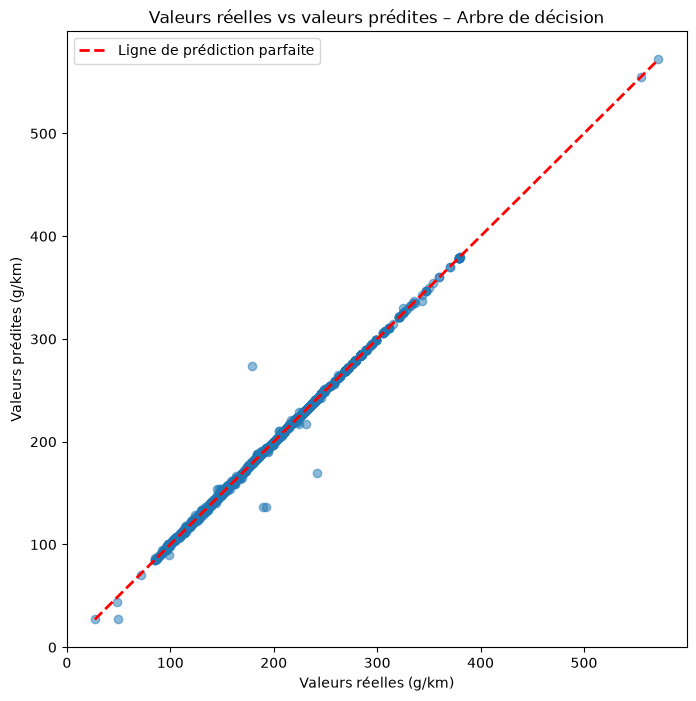

In [39]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred_tree,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2,
    label="Ligne de prédiction parfaite"
)

plt.xlabel("Valeurs réelles (g/km)")
plt.ylabel("Valeurs prédites (g/km)")
plt.title("Valeurs réelles vs valeurs prédites – Arbre de décision")

plt.legend()

plt.show()

Le nuage de points met en évidence une excellente concordance entre les valeurs réelles et les valeurs prédites par l'Arbre de décision. La quasi-totalité des observations est alignée le long de la diagonale représentant une prédiction parfaite, ce qui traduit une très grande précision des prédictions.

Seules quelques observations présentent un écart plus marqué par rapport à la diagonale, mais elles restent très peu nombreuses au regard de l'ensemble des données. Les valeurs les plus élevées des émissions de CO₂ sont également correctement prédites, ce qui confirme la capacité du modèle à s'adapter à l'ensemble du domaine de valeurs.

Cette représentation graphique est cohérente avec les excellentes performances obtenues par le modèle (R² = 0,9983, RMSE = 1,43 g/km) et confirme que l'Arbre de décision présente les meilleures performances parmi les modèles évalués dans cette étude

### Analyse des résidus

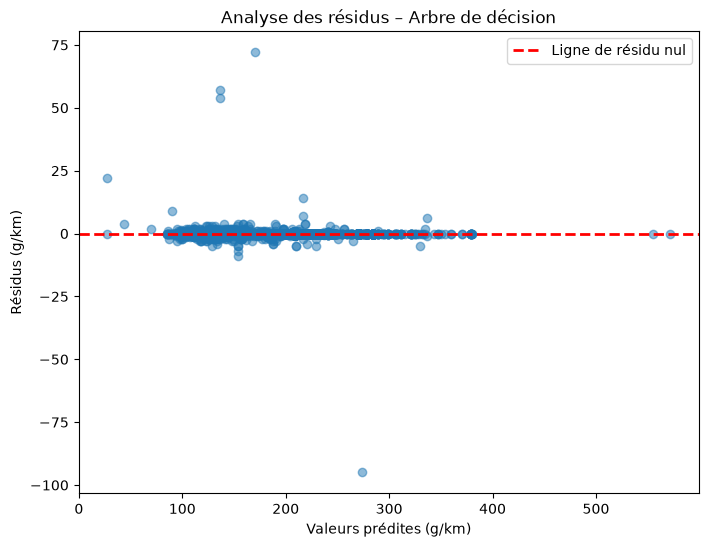

In [40]:
# Calcul des résidus
residus_tree = y_test - y_pred_tree

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_tree,
    residus_tree,
    alpha=0.5
)

# Ligne représentant un résidu nul
plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Ligne de résidu nul"
)

plt.xlabel("Valeurs prédites (g/km)")
plt.ylabel("Résidus (g/km)")
plt.title("Analyse des résidus – Arbre de décision")

plt.legend()

plt.show()

Le graphique des résidus montre que les erreurs de prédiction de l'Arbre de décision sont très majoritairement concentrées autour de la ligne de résidu nul. Cette répartition traduit une excellente qualité d'ajustement et confirme que le modèle ne présente pas de biais systématique dans ses prédictions.

La dispersion des résidus est très faible pour la majorité des observations, ce qui est cohérent avec les excellentes performances obtenues (R² = 0,9983, RMSE = 1,43 g/km). Quelques observations isolées présentent toutefois des résidus plus importants, aussi bien positifs que négatifs, mais elles restent très peu nombreuses au regard de l'ensemble des données et n'affectent pas les performances globales du modèle.

Cette analyse confirme que l'Arbre de décision présente une excellente capacité de prédiction tout en conservant une bonne qualité de généralisation. La courbe d'apprentissage permettra néanmoins de vérifier que ces performances ne résultent pas d'un phénomène de surapprentissage.

### Courbe d'apprentissage

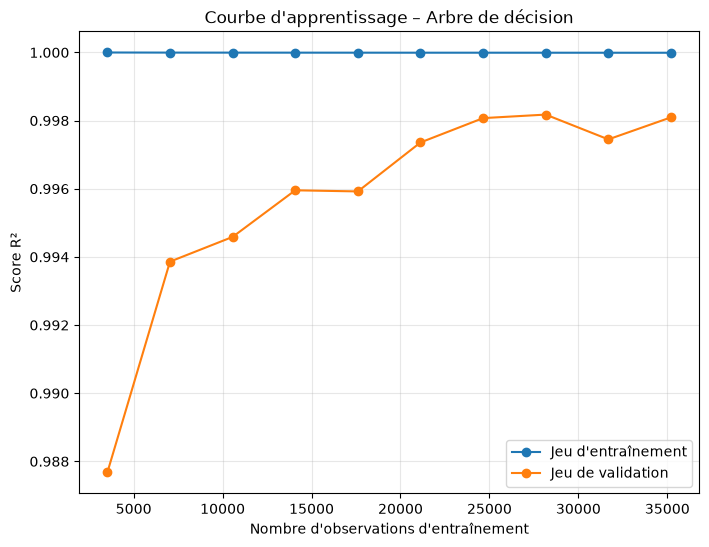

In [41]:

# Calcul des courbes d'apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    estimator=tree,
    X=X_train,
    y=y_train,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Moyenne des scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# Graphique
plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Jeu d'entraînement"
)

plt.plot(
    train_sizes,
    test_mean,
    marker="o",
    label="Jeu de validation"
)

plt.xlabel("Nombre d'observations d'entraînement")
plt.ylabel("Score R²")
plt.title("Courbe d'apprentissage – Arbre de décision")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

La courbe d'apprentissage montre que le score obtenu sur le jeu d'entraînement reste quasiment parfait (R² ≈ 1,00) tout au long de l'apprentissage, tandis que le score du jeu de validation augmente progressivement avec la taille du jeu de données avant de se stabiliser autour de 0,998.

Un léger écart persiste entre les deux courbes en fin d'apprentissage, ce qui traduit un léger phénomène de surapprentissage, fréquent pour un arbre de décision non élagué. Toutefois, cet écart reste très faible et n'altère pas la qualité globale des prédictions.

Cette analyse confirme que l'Arbre de décision présente les meilleures performances parmi les modèles évalués tout en conservant une excellente capacité de généralisation. Les performances observées sur le jeu de validation montrent que le modèle reste robuste et adapté à la prédiction des émissions de CO₂.

### Importance des variables

In [42]:
import pandas as pd

importance = pd.DataFrame({
    "Variable": X_train.columns,
    "Importance": tree.feature_importances_
})

importance.sort_values("Importance", ascending=False).head(15)

,Variable,Importance
1,conso_mixte,0.976651
58,cod_cbr_GO,0.011226
2,co_typ_1,0.003658
0,puiss_max,0.002778
3,nox,0.001916
6,masse_ordma_max,0.001208
57,cod_cbr_GN/ES,0.000632
71,gamme_INFERIEURE,0.000529
72,gamme_LUXE,0.000400
59,cod_cbr_GP/ES,0.000318


L'analyse de l'importance des variables montre que la consommation mixte (`conso_mixte`) constitue de loin le principal facteur utilisé par l'arbre de décision. À elle seule, cette variable représente environ 97,7 % de l'importance totale du modèle.

Les autres variables, telles que le type de carburant (`cod_cbr`), les émissions de CO (`co_typ_1`), la puissance maximale (`puiss_max`) ou les émissions de NOx (`nox`), contribuent de manière beaucoup plus limitée à la prédiction.

Ces résultats sont cohérents avec l'analyse exploratoire réalisée précédemment, qui avait déjà mis en évidence une très forte corrélation entre la consommation mixte et les émissions de CO₂. Cette importance très élevée explique également les excellentes performances obtenues par l'Arbre de décision. Toutefois, elle confirme que la variable conso_mixte domine largement les prédictions, ce qui justifie les expérimentations réalisées ultérieurement sans cette variable afin d'évaluer le risque de fuite d'information.

## Comparaison des modèles

Les performances des différents modèles de régression sont comparées à l'aide de quatre indicateurs : le MAE (Mean Absolute Error), le RMSE (Root Mean Squared Error), le coefficient de détermination (R²) et le MAPE (Mean Absolute Percentage Error).

Cette comparaison permet d'identifier le modèle offrant le meilleur compromis entre précision des prédictions et capacité de généralisation.

In [43]:
comparaison = pd.DataFrame({
    "Modèle": [
        "Régression linéaire",
        "Ridge",
        "Lasso",
        "Arbre de décision"
    ],
    "MAE": [
        mae_lin,
        mae_ridge,
        mae_lasso,
        mae_tree
    ],
    "RMSE": [
        rmse_lin,
        rmse_ridge,
        rmse_lasso,
        rmse_tree
    ],
    "R²": [
        r2_lin,
        r2_ridge,
        r2_lasso,
        r2_tree
    ],
    "MAPE": [
        mape_lin,
        mape_ridge,
        mape_lasso,
        mape_tree
    ]
})

comparaison = comparaison.round({
    "MAE": 2,
    "RMSE": 2,
    "R²": 4,
    "MAPE": 4
})

comparaison

,Modèle,MAE,RMSE,R²,MAPE
0,Régression linéaire,1.10,1.80,0.9973,0.0061
1,Ridge,1.12,1.82,0.9972,0.0062
2,Lasso,3.94,5.65,0.9730,0.0206
3,Arbre de décision,0.09,1.43,0.9983,0.0006


### Analyse comparative des modèles

Les résultats montrent que les quatre modèles obtiennent des performances élevées sur ce jeu de données, mais avec des différences notables.

La régression linéaire constitue une excellente référence. Malgré sa simplicité, elle explique près de 99,7 % de la variabilité des émissions de CO₂ et présente des erreurs de prédiction très faibles.

La régression Ridge obtient des performances très proches de celles de la régression linéaire. Dans ce contexte, la pénalisation L2 n'apporte pas d'amélioration significative des performances.

La régression Lasso présente des performances plus faibles. La pénalisation L1 simplifie fortement le modèle en réduisant l'influence de certaines variables, ce qui entraîne une diminution de la qualité des prédictions.

L'Arbre de décision présente les meilleures performances parmi les modèles évalués, avec les erreurs de prédiction les plus faibles et le coefficient de détermination le plus élevé. Les analyses graphiques confirment la très bonne qualité de ses prédictions. Bien qu'un léger surapprentissage soit observé sur la courbe d'apprentissage, les performances sur le jeu de validation restent excellentes, ce qui confirme une très bonne capacité de généralisation.

## Exploration automatique des modèles de régression avec LazyRegressor

Afin d'élargir la comparaison à un plus grand nombre d'algorithmes, une exploration automatique est réalisée à l'aide de LazyRegressor. Cet outil entraîne plusieurs modèles de régression avec leurs paramètres par défaut afin d'identifier les approches les plus prometteuses avant une éventuelle phase d'optimisation.

### Préparation de l'environnement d'exécution

Certaines variables d'environnement sont définies afin de limiter le nombre de threads utilisés par les bibliothèques numériques. Cette configuration améliore la stabilité de l'exécution de LazyRegressor dans l'environnement de travail utilisé.

In [4]:

import os

os.environ["JOBLIB_START_METHOD"] = "fork"

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

from lazypredict import LazyRegressor
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1)).fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)



reg = LazyRegressor(verbose=0,ignore_warnings=True, custom_metric=None )
models,predictions = reg.fit(X_train_scaled, X_test_scaled, y_train, y_test)

models_display = models.copy()

# Arrondi des colonnes numériques
models_display = models_display.round(4)

# Affichage sans notation scientifique
pd.set_option(
    'display.float_format',
    lambda x: f'{x:.4f}'
)

display(models_display)

models_display.to_excel(
    "LazyPredict_resultats.xlsx"
)

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
ExtraTreesRegressor,0.9997,0.9997,0.6046,3.2585
RandomForestRegressor,0.9991,0.9991,1.0046,4.9814
BaggingRegressor,0.9989,0.9989,1.1529,0.5639
ExtraTreeRegressor,0.9985,0.9985,1.3411,0.0675
DecisionTreeRegressor,0.9983,0.9983,1.4302,0.1131
MLPRegressor,0.9979,0.9980,1.5547,7.7383
GradientBoostingRegressor,0.9976,0.9976,1.6711,3.0885
RidgeCV,0.9972,0.9973,1.7984,0.1535
Ridge,0.9972,0.9973,1.7986,0.0479


### Interprétation des résultats de LazyRegressor

L'exploration automatique réalisée à l'aide de LazyRegressor a permis de comparer rapidement un large ensemble de modèles de régression en utilisant leurs paramètres par défaut. Cette approche constitue une première étape exploratoire visant à identifier les algorithmes les plus prometteurs avant une éventuelle phase d'optimisation des hyperparamètres.

Les résultats mettent en évidence les excellentes performances de plusieurs modèles d'ensemble, notamment ExtraTreesRegressor, RandomForestRegressor, BaggingRegressor et ExtraTreeRegressor, qui obtiennent des coefficients de détermination (R²) très élevés ainsi que des erreurs de prédiction (RMSE) particulièrement faibles. Ces résultats montrent que les caractéristiques techniques des véhicules permettent de prédire avec une grande précision les émissions de CO₂.

Les modèles linéaires, tels que LinearRegression, Ridge, RidgeCV et BayesianRidge, obtiennent également d'excellentes performances, avec des coefficients de détermination supérieurs à 0,99. Cela confirme que la relation entre les variables explicatives retenues et les émissions de CO₂ est largement linéaire lorsque les variables les plus informatives sont conservées.

À l'inverse, certains modèles comme DummyRegressor, Lars ou SGDRegressor affichent des performances nettement plus faibles. Ces résultats montrent que ces approches sont moins adaptées à la structure de ce jeu de données ou nécessiteraient un réglage plus fin de leurs hyperparamètres pour atteindre un niveau de performance comparable.

Ces résultats doivent toutefois être interprétés avec prudence. Plusieurs variables de consommation de carburant présentent une corrélation très forte avec la variable cible (CO₂), ce qui peut contribuer à ces excellentes performances. Afin d'évaluer la robustesse des modèles et de limiter le risque de dépendance à des variables fortement corrélées, des expérimentations complémentaires ont été réalisées en supprimant successivement certaines variables telles que conso_mixte, co_typ_1 et nox.

Il convient également de rappeler que LazyRegressor constitue un outil d'aide à la décision et non un outil de sélection définitive du modèle. Son objectif est de fournir une comparaison rapide de nombreux algorithmes afin d'orienter les expérimentations et les analyses plus approfondies.

Enfin, les performances présentées correspondent aux paramètres par défaut des différents algorithmes. Elles devront être confirmées et éventuellement améliorées lors d'une phase d'optimisation des hyperparamètres (GridSearchCV ou RandomizedSearchCV). Le choix du modèle final reposera non seulement sur ses performances prédictives, mais également sur sa robustesse, son interprétabilité, son coût de calcul et sa capacité de généralisation sur des données inédites.

## Conclusion générale de la modélisation

Cette phase de modélisation a permis d'évaluer plusieurs approches de régression afin de prédire les émissions de CO₂ des véhicules à partir de leurs caractéristiques techniques. Quatre modèles ont été étudiés en détail : la régression linéaire, Ridge, Lasso et l'Arbre de décision.

Dans l'ensemble, les modèles obtiennent d'excellentes performances, confirmant l'existence d'une relation très forte entre les variables explicatives retenues et les émissions de CO₂. La régression linéaire constitue un excellent modèle de référence. Malgré sa simplicité, elle explique près de 99,7 % de la variabilité des émissions de CO₂ et présente une très bonne capacité de généralisation.

La régression Ridge produit des performances quasiment identiques, montrant que l'ajout d'une régularisation L2 n'apporte pas de gain significatif sur ce jeu de données. À l'inverse, la régression Lasso obtient des résultats légèrement moins performants. La pénalisation L1 simplifie le modèle en réduisant l'influence de certaines variables explicatives, mais cette simplification s'accompagne d'une légère diminution de la précision des prédictions.

Parmi les modèles étudiés, l'Arbre de décision présente les meilleures performances. Les analyses quantitatives et graphiques (valeurs réelles vs prédites, résidus et courbes d'apprentissage) confirment la très bonne qualité de ses prédictions et sa capacité de généralisation, malgré un léger surapprentissage observé sur la courbe d'apprentissage.

L'exploration complémentaire réalisée à l'aide de LazyRegressor (dans l'environnement de travail du groupe) a permis d'élargir cette comparaison à un plus grand nombre d'algorithmes de régression. Elle met notamment en évidence les très bonnes performances de modèles d'ensemble tels qu'ExtraTreesRegressor et RandomForestRegressor, qui constituent des pistes intéressantes pour les phases d'optimisation.

Enfin, les expérimentations réalisées avec différents jeux de variables, notamment sans conso_mixte, co_typ_1 et nox, ont permis d'évaluer l'influence de variables fortement corrélées à la cible. Elles contribuent à renforcer la robustesse de l'analyse et à limiter le risque de dépendance excessive à des variables très proches de la variable cible.

La suite du projet consistera à optimiser les modèles les plus prometteurs, à approfondir leur interprétabilité à l'aide de SHAP et à retenir le modèle offrant le meilleur compromis entre précision, robustesse, interprétabilité et capacité de généralisation.

## Interprétabilité des modèles avec SHAP

### Introduction

Afin de compléter l'évaluation des performances des différents modèles, une analyse d'interprétabilité a été réalisée à l'aide de la méthode SHAP (SHapley Additive exPlanations).

Contrairement aux mesures globales d'importance des variables, SHAP permet d'expliquer la contribution de chaque variable à chaque prédiction. Cette approche offre une interprétation locale et globale des modèles en quantifiant l'influence de chaque caractéristique sur les prédictions.

L'objectif de cette analyse est de mieux comprendre les mécanismes de décision des différents modèles étudiés et d'identifier les variables qui influencent le plus les émissions de CO₂.

### Régression linéaire

Afin de mieux comprendre les mécanismes de décision du modèle de régression linéaire, une analyse d'interprétabilité est réalisée à l'aide de la méthode **SHAP (SHapley Additive exPlanations)**.

Cette méthode permet d'évaluer la contribution de chaque variable explicative aux prédictions du modèle. Trois représentations complémentaires sont proposées :

- une importance globale des variables ;
- un graphique illustrant l'impact de chaque variable sur les prédictions ;
- une explication détaillée d'une prédiction individuelle.

Ces analyses complètent les métriques de performance en apportant une meilleure compréhension du fonctionnement du modèle.

Background dataset has 1000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1000 when initializing the masker.


Dimension des valeurs SHAP : (1000, 91)


,Variable,SHAP
1,conso_mixte,35.871621
58,cod_cbr_GO,4.737139
3,nox,2.176152
51,cod_cbr_ES,-2.131322
73,gamme_MOY-INFER,-1.532334
...,...,...
80,typ_boite_nb_rapp_A 8,-0.000000
84,typ_boite_nb_rapp_D 7,-0.000000
87,typ_boite_nb_rapp_M 7,0.000000
88,typ_boite_nb_rapp_S 6,0.000000


Observation analysée : 59
Index d'origine : 18137


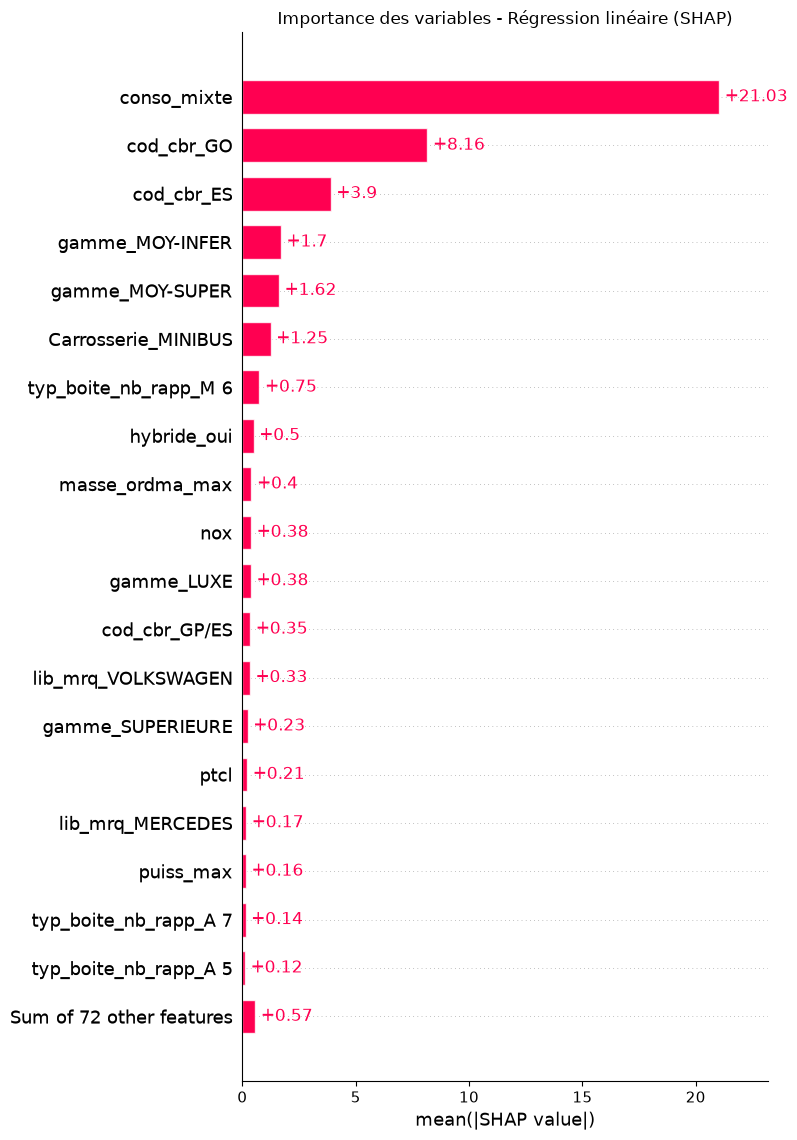

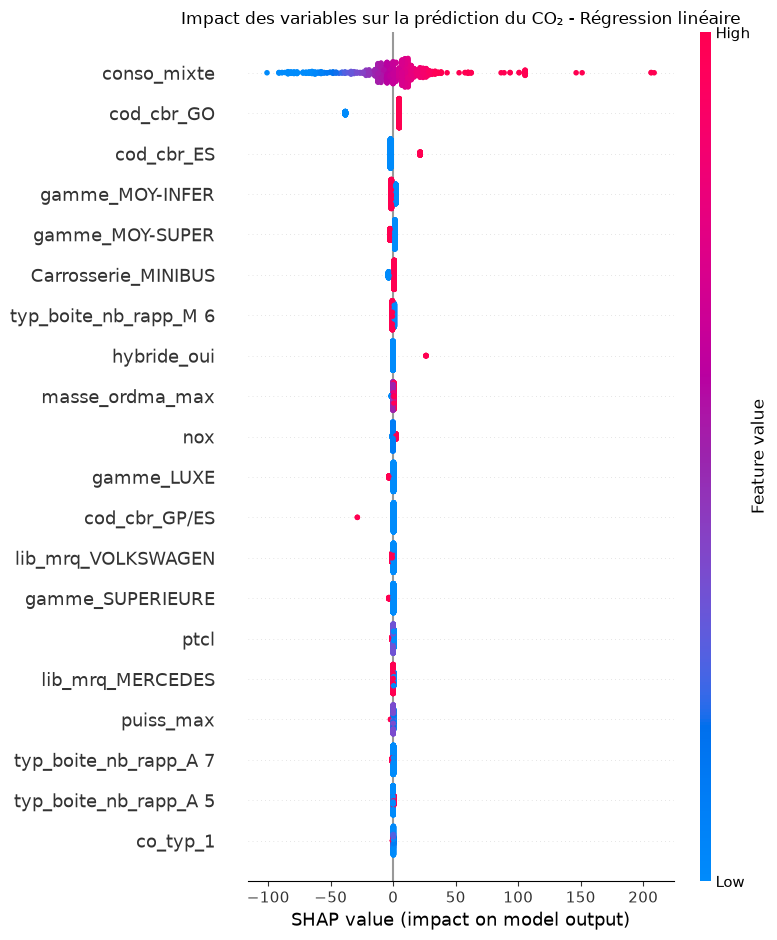

Explication de la prédiction de l'observation : 59
Index réel de l'observation : 18137


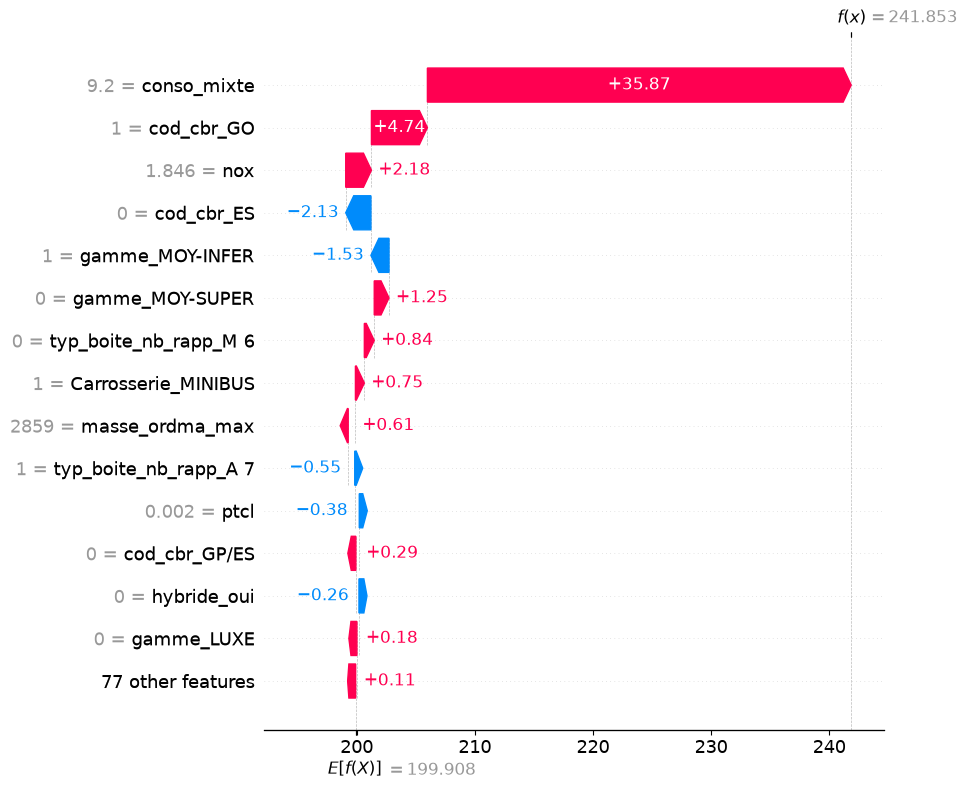

In [44]:
# ==========================================================
# SHAP - Régression linéaire
# ==========================================================

# ----------------------------------------------------------
# 1. Sélection d'un échantillon pour l'analyse SHAP
# ----------------------------------------------------------

X_train_sample = X_train.sample(
    n=1000,
    random_state=42
)

# ----------------------------------------------------------
# 2. Création du jeu de référence (background)
# ----------------------------------------------------------

X_background = X_train.sample(
    n=1000,
    random_state=42
)

# ----------------------------------------------------------
# 3. Construction de l'explainer SHAP
# ----------------------------------------------------------

explainer = shap.LinearExplainer(
    reg_lin,
    X_background
)

# ----------------------------------------------------------
# 4. Calcul des valeurs SHAP
# ----------------------------------------------------------

shap_values = explainer(X_train_sample)

# Vérification des dimensions
print(
    "Dimension des valeurs SHAP :",
    shap_values.values.shape
)

# ==========================================================
# GRAPHIQUE 1 : IMPORTANCE GLOBALE DES VARIABLES
# ==========================================================

plt.figure(figsize=(10, 8))

display(
    pd.DataFrame(
        {
            "Variable": X_train_sample.columns,
            "SHAP": shap_values.values[59]
        }
    )
    .sort_values(
        "SHAP",
        key=abs,
        ascending=False
    )
)

print(
    "Observation analysée :",
    59
)

print(
    "Index d'origine :",
    X_train_sample.index[59]
)

shap.plots.bar(
    shap_values,
    max_display=20,
    show=False
)

plt.title(
    "Importance des variables - Régression linéaire (SHAP)"
)

plt.tight_layout()

plt.show()

# ==========================================================
# GRAPHIQUE 2 : IMPACT DES VARIABLES SUR LES PREDICTIONS
# ==========================================================

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values.values,
    X_train_sample,
    max_display=20,
    show=False
)

plt.title(
    "Impact des variables sur la prédiction du CO₂ - Régression linéaire"
)

plt.tight_layout()

plt.show()

# ==========================================================
# GRAPHIQUE 3 : EXPLICATION D'UNE PREDICTION INDIVIDUELLE
# ==========================================================

# Observation utilisée pour l'explication individuelle
index = 59

print(
    "Explication de la prédiction de l'observation :",
    index
)

print(
    "Index réel de l'observation :",
    X_train_sample.index[index]
)

shap.plots.waterfall(
    shap_values[index],
    max_display=15
)

### Interprétation des résultats

L'analyse SHAP apporte une interprétation complémentaire des performances de la régression linéaire en identifiant les variables qui contribuent le plus aux prédictions du modèle.

Le graphique d'importance globale montre que la consommation mixte (conso_mixte) constitue de loin la variable la plus influente. Sa contribution moyenne est nettement supérieure à celle des autres variables, ce qui confirme les résultats obtenus lors de l'analyse exploratoire et de la modélisation. Les variables liées au type de carburant (cod_cbr_GO, cod_cbr_ES) ainsi que certaines caractéristiques techniques du véhicule participent également aux prédictions, mais avec une influence beaucoup plus limitée.

Le graphique de synthèse (summary plot) met en évidence que les valeurs élevées de conso_mixte augmentent fortement les émissions de CO₂ prédites, tandis que les faibles consommations contribuent à les diminuer. Les autres variables présentent des contributions plus faibles et restent majoritairement concentrées autour de zéro.

Enfin, l'explication individuelle confirme ces observations. Pour le véhicule étudié, la consommation mixte représente l'essentiel de la prédiction, tandis que les autres variables n'apportent que des ajustements secondaires, positifs ou négatifs. Cette représentation permet de comprendre précisément la contribution de chaque variable à une prédiction particulière.

Dans l'ensemble, l'analyse SHAP confirme que la régression linéaire s'appuie principalement sur des variables présentant un lien physique direct avec les émissions de CO₂. Elle met également en évidence la forte dépendance du modèle à la variable conso_mixte, ce qui justifie les expérimentations réalisées par la suite en supprimant cette variable, ainsi que co_typ_1 et nox, Cette observation constitue la principale motivation des expérimentations présentées dans le notebook d'expérience, dont l'objectif est d'évaluer la capacité des modèles à conserver de bonnes performances après la suppression des variables les plus fortement corrélées à la cible.

### Ridge

L'analyse SHAP est appliquée au modèle Ridge afin d'interpréter les variables qui influencent le plus ses prédictions. Les mêmes représentations que pour la régression linéaire sont utilisées afin de faciliter la comparaison entre les deux modèles et d'évaluer l'effet de la régularisation L2 sur l'importance des variables.

Background dataset has 1000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1000 when initializing the masker.


Dimension des valeurs SHAP : (1000, 91)


,Variable,SHAP
1,conso_mixte,35.821730
58,cod_cbr_GO,4.669834
51,cod_cbr_ES,-2.061080
73,gamme_MOY-INFER,-1.461891
75,gamme_MOY-SUPER,1.205653
...,...,...
80,typ_boite_nb_rapp_A 8,-0.000000
84,typ_boite_nb_rapp_D 7,-0.000000
87,typ_boite_nb_rapp_M 7,0.000000
88,typ_boite_nb_rapp_S 6,0.000000


Observation analysée : 59
Index d'origine : 18137


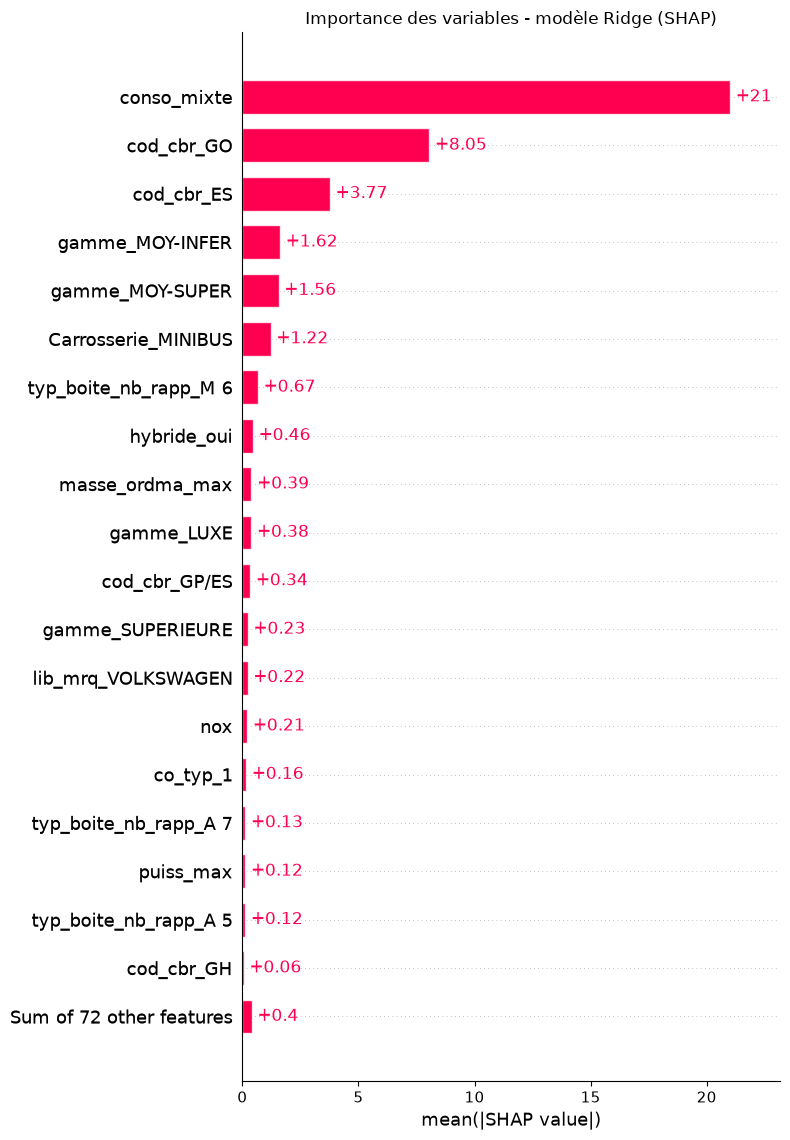

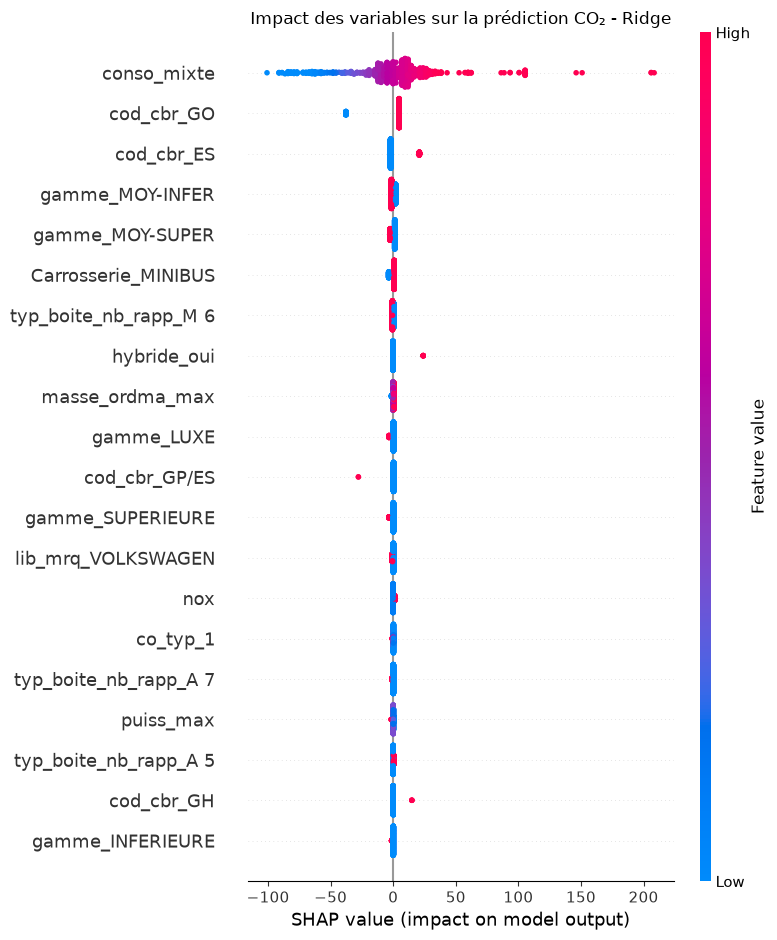

Explication de la prédiction de l'observation : 59
Index d'origine : 18137


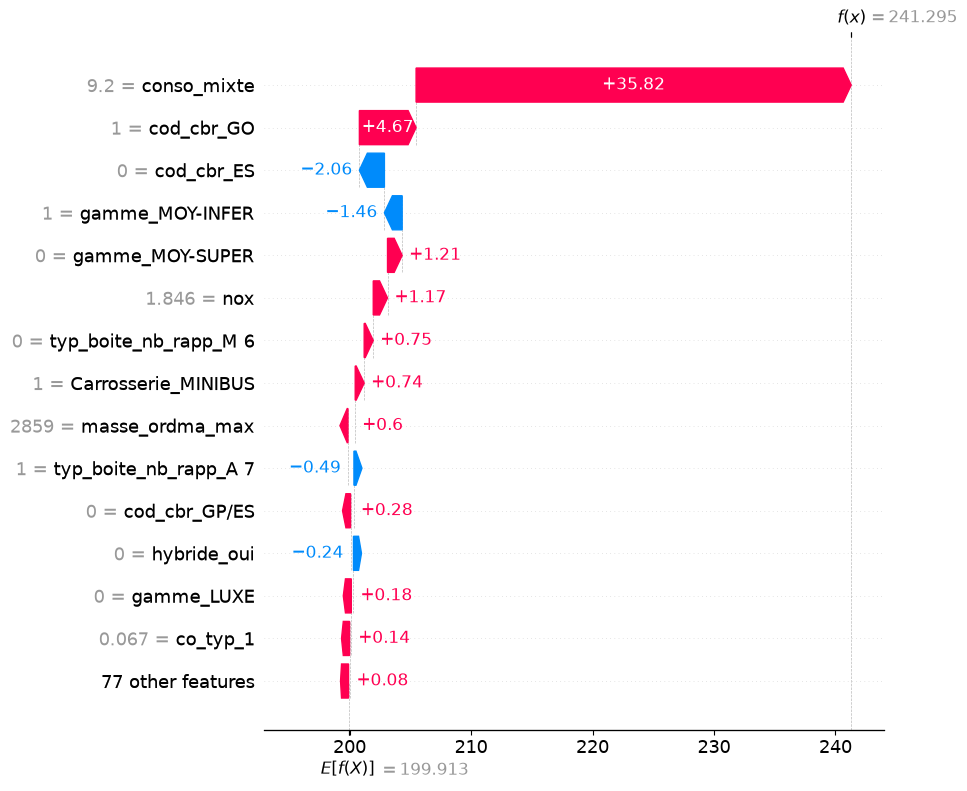

In [45]:
# ==========================================================
# SHAP - Ridge
# ==========================================================

# ----------------------------------------------------------
# 1) Échantillon pour l'analyse SHAP
# ----------------------------------------------------------

X_train_sample = X_train.sample(
    1000,
    random_state=42
)

# ----------------------------------------------------------
# 2) Jeu de référence (background)
# ----------------------------------------------------------

X_background = X_train.sample(
    1000,
    random_state=42
)

# ----------------------------------------------------------
# 3) Création de l'explainer SHAP
# ----------------------------------------------------------

explainer = shap.LinearExplainer(
    ridge,
    X_background
)

# ----------------------------------------------------------
# 4) Calcul des valeurs SHAP
# ----------------------------------------------------------

shap_values = explainer(
    X_train_sample
)

print(
    "Dimension des valeurs SHAP :",
    shap_values.values.shape
)

# ==========================================================
# GRAPHIQUE 1 : IMPORTANCE GLOBALE DES VARIABLES
# ==========================================================

plt.figure(figsize=(10, 8))

display(
    pd.DataFrame(
        {
            "Variable": X_train_sample.columns,
            "SHAP": shap_values.values[59]
        }
    )
    .sort_values(
        "SHAP",
        key=abs,
        ascending=False
    )
)

print(
    "Observation analysée :",
    59
)

print(
    "Index d'origine :",
    X_train_sample.index[59]
)

shap.plots.bar(
    shap_values,
    max_display=20,
    show=False
)

plt.title(
    "Importance des variables - modèle Ridge (SHAP)"
)

plt.tight_layout()

plt.show()

# ==========================================================
# GRAPHIQUE 2 : IMPACT DES VARIABLES SUR LE CO₂
# ==========================================================

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values.values,
    X_train_sample,
    max_display=20,
    show=False
)

plt.title(
    "Impact des variables sur la prédiction CO₂ - Ridge"
)

plt.tight_layout()

plt.show()

# ==========================================================
# GRAPHIQUE 3 : EXPLICATION D'UNE PRÉDICTION INDIVIDUELLE
# ==========================================================

index = 59

print(
    "Explication de la prédiction de l'observation :",
    index
)

print(
    "Index d'origine :",
    X_train_sample.index[index]
)

shap.plots.waterfall(
    shap_values[index],
    max_display=15
)

### Interprétation des résultats

L'analyse SHAP du modèle Ridge confirme les observations obtenues avec la régression linéaire. La consommation mixte (conso_mixte) demeure de très loin la variable la plus influente dans les prédictions, avec une contribution moyenne largement supérieure à celle des autres variables. Les variables liées au type de carburant (cod_cbr_GO, cod_cbr_ES) ainsi que certaines caractéristiques techniques du véhicule contribuent également aux prédictions, mais leur influence reste nettement plus limitée.

Le graphique de synthèse montre que les valeurs élevées de conso_mixte augmentent fortement les émissions de CO₂ prédites, tandis que les faibles consommations contribuent à les diminuer. Les autres variables présentent des contributions plus faibles et demeurent concentrées autour de zéro, traduisant un impact secondaire sur la prédiction finale.

L'explication individuelle confirme cette hiérarchie des variables. Pour l'observation étudiée, la consommation mixte constitue l'essentiel de la prédiction, tandis que les autres variables n'apportent que des ajustements plus modestes, positifs ou négatifs.

Dans l'ensemble, cette analyse montre que la régularisation L2 introduite par le modèle Ridge ne modifie pas de manière significative l'importance relative des variables explicatives. Les mécanismes de décision restent très proches de ceux observés pour la régression linéaire, ce qui est cohérent avec les performances très similaires obtenues par les deux modèles. Cette observation constitue également la principale motivation des expérimentations présentées dans le notebook d'expérience, dont l'objectif est d'évaluer la capacité des modèles à conserver de bonnes performances après la suppression des variables les plus fortement corrélées à la cible.

### Lasso

L'analyse SHAP est réalisée sur le modèle Lasso afin d'étudier l'influence de la régularisation L1 sur les contributions des variables explicatives. Les résultats sont comparés à ceux obtenus avec les modèles linéaires précédents.

Background dataset has 1000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1000 when initializing the masker.


Dimension des valeurs SHAP : (1000, 91)


,Variable,SHAP
1,conso_mixte,32.490043
5,masse_ordma_min,7.081500
6,masse_ordma_max,1.925022
0,puiss_max,-1.015385
2,co_typ_1,0.000000
...,...,...
86,typ_boite_nb_rapp_M 6,0.000000
87,typ_boite_nb_rapp_M 7,0.000000
88,typ_boite_nb_rapp_S 6,0.000000
89,typ_boite_nb_rapp_V .,0.000000


Observation analysée : 59
Index d'origine : 18137


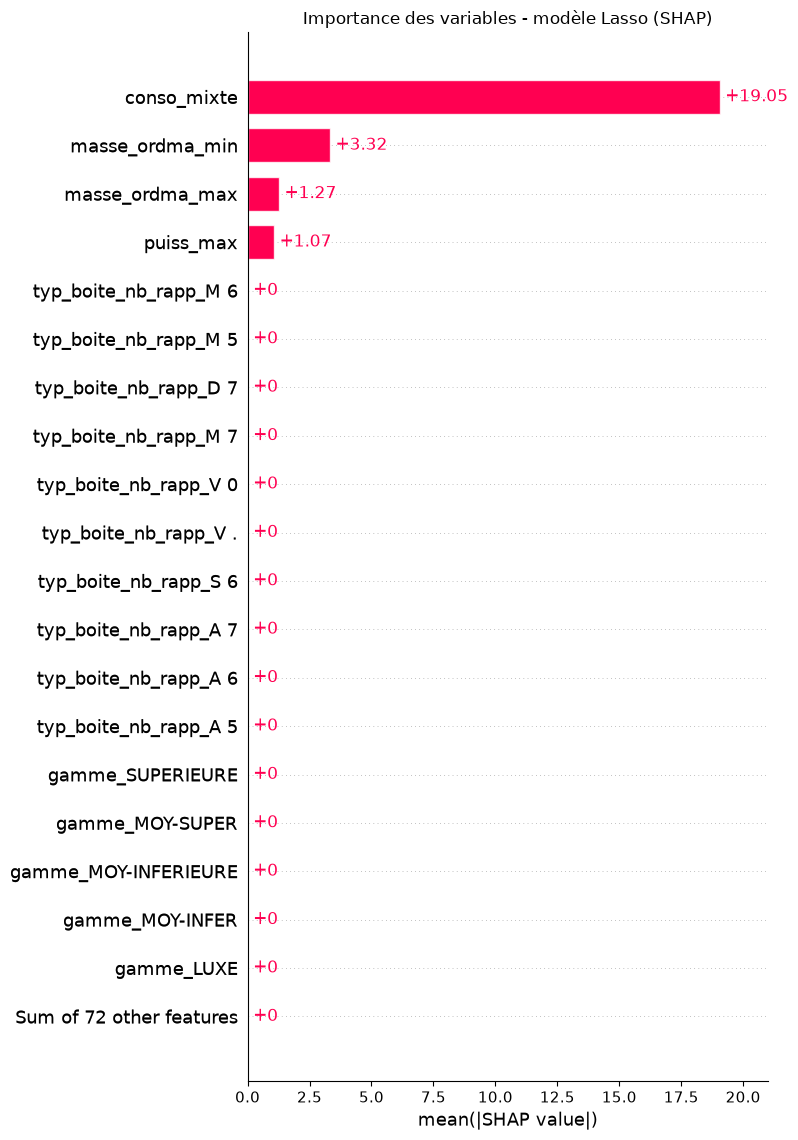

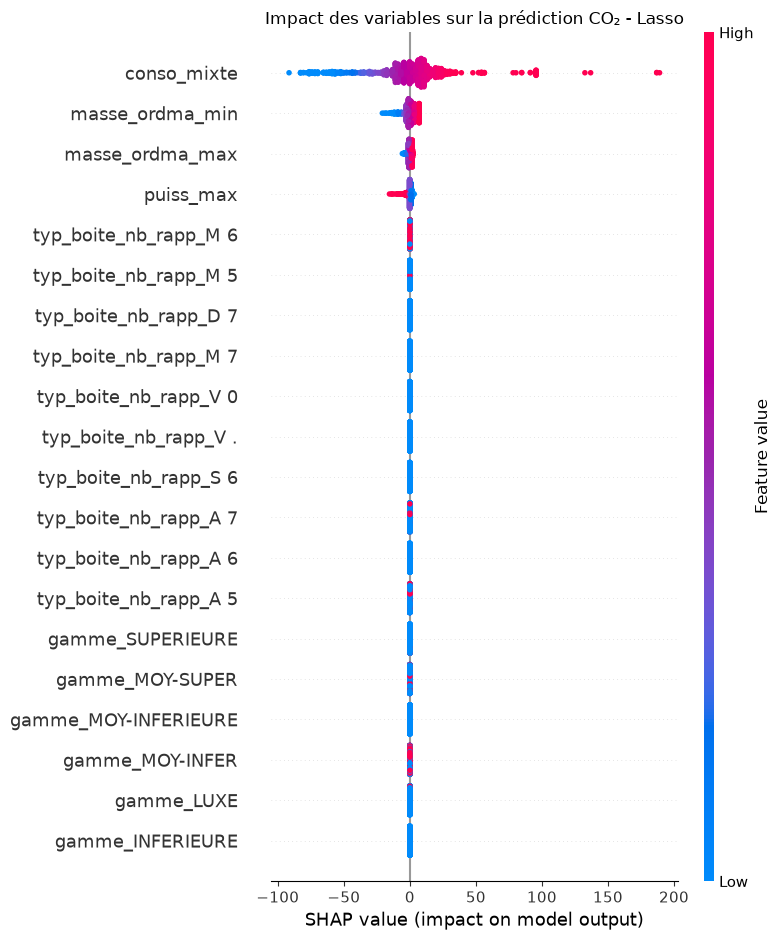

Explication de la prédiction de l'observation : 59
Index d'origine : 18137


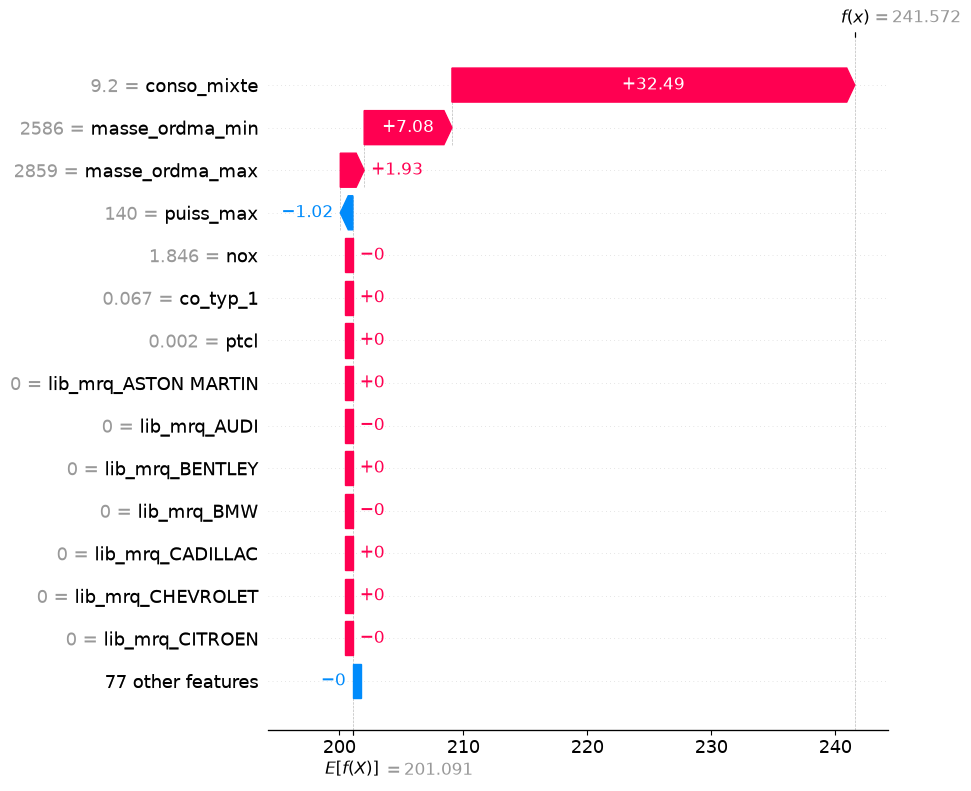

In [46]:
# ==========================================================
# SHAP - Lasso
# ==========================================================

# ----------------------------------------------------------
# 1) Échantillon pour l'analyse SHAP
# ----------------------------------------------------------

X_train_sample = X_train.sample(
    1000,
    random_state=42
)

# ----------------------------------------------------------
# 2) Jeu de référence (background)
# ----------------------------------------------------------

X_background = X_train.sample(
    1000,
    random_state=42
)

# ----------------------------------------------------------
# 3) Création de l'explainer SHAP
# ----------------------------------------------------------

explainer = shap.LinearExplainer(
    lasso,
    X_background
)

# ----------------------------------------------------------
# 4) Calcul des valeurs SHAP
# ----------------------------------------------------------

shap_values = explainer(
    X_train_sample
)

print(
    "Dimension des valeurs SHAP :",
    shap_values.values.shape
)

# ==========================================================
# GRAPHIQUE 1 : IMPORTANCE GLOBALE DES VARIABLES
# ==========================================================

plt.figure(figsize=(10, 8))

display(
    pd.DataFrame(
        {
            "Variable": X_train_sample.columns,
            "SHAP": shap_values.values[59]
        }
    )
    .sort_values(
        "SHAP",
        key=abs,
        ascending=False
    )
)

print(
    "Observation analysée :",
    59
)

print(
    "Index d'origine :",
    X_train_sample.index[59]
)

shap.plots.bar(
    shap_values,
    max_display=20,
    show=False
)

plt.title(
    "Importance des variables - modèle Lasso (SHAP)"
)

plt.tight_layout()

plt.show()

# ==========================================================
# GRAPHIQUE 2 : IMPACT DES VARIABLES SUR LA PRÉDICTION CO₂
# ==========================================================

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values.values,
    X_train_sample,
    max_display=20,
    show=False
)

plt.title(
    "Impact des variables sur la prédiction CO₂ - Lasso"
)

plt.tight_layout()

plt.show()

# ==========================================================
# GRAPHIQUE 3 : EXPLICATION D'UNE PRÉDICTION INDIVIDUELLE
# ==========================================================

index = 59

print(
    "Explication de la prédiction de l'observation :",
    index
)

print(
    "Index d'origine :",
    X_train_sample.index[index]
)

shap.plots.waterfall(
    shap_values[index],
    max_display=15
)

### Interprétation des résultats

L'analyse SHAP du modèle Lasso met en évidence un fonctionnement sensiblement différent de celui des modèles de régression linéaire et Ridge. La consommation mixte (conso_mixte) reste la variable la plus influente dans les prédictions, mais le nombre de variables contribuant réellement au modèle est nettement plus réduit.

Le graphique d'importance globale montre que seules quelques variables, notamment conso_mixte, masse_ordma_min, masse_ordma_max et puiss_max, conservent une contribution notable. À l'inverse, de nombreuses variables présentent une contribution SHAP nulle ou quasi nulle, traduisant l'effet de la régularisation L1, qui réduit automatiquement les coefficients des variables les moins utiles jusqu'à les annuler.

Le graphique de synthèse confirme cette simplification du modèle. Les fortes valeurs de conso_mixte augmentent les émissions de CO₂ prédites, tandis que les autres variables exercent une influence beaucoup plus limitée. La majorité des variables restantes est concentrée autour de zéro, ce qui montre qu'elles interviennent peu dans les prédictions.

L'explication individuelle de l'observation analysée illustre également ce comportement. La prédiction repose essentiellement sur conso_mixte, complétée par quelques variables techniques comme masse_ordma_min et masse_ordma_max, tandis que la plupart des autres variables n'ont pratiquement aucun effet sur le résultat final.

Dans l'ensemble, cette analyse confirme que la régularisation L1 simplifie fortement le modèle en conservant uniquement les variables les plus informatives. Cette réduction de la complexité améliore l'interprétabilité du modèle, mais s'accompagne d'une légère diminution des performances prédictives, déjà observée lors de l'évaluation des métriques (MAE, RMSE et R²).

### Arbre de décision

L'analyse SHAP est appliquée à l'Arbre de décision afin d'identifier les variables les plus influentes dans les prédictions et de comparer leur importance avec celles observées pour les modèles linéaires.

Dimension des valeurs SHAP : (1000, 91)


,Variable,SHAP
1,conso_mixte,37.856613
2,co_typ_1,2.295771
58,cod_cbr_GO,0.471972
5,masse_ordma_min,0.215937
72,gamme_LUXE,0.211344
...,...,...
40,lib_mrq_ROLLS-ROYCE,0.000000
64,Carrosserie_COMBISPCACE,0.000000
84,typ_boite_nb_rapp_D 7,0.000000
88,typ_boite_nb_rapp_S 6,0.000000


Observation analysée : 59
Index d'origine : 18137


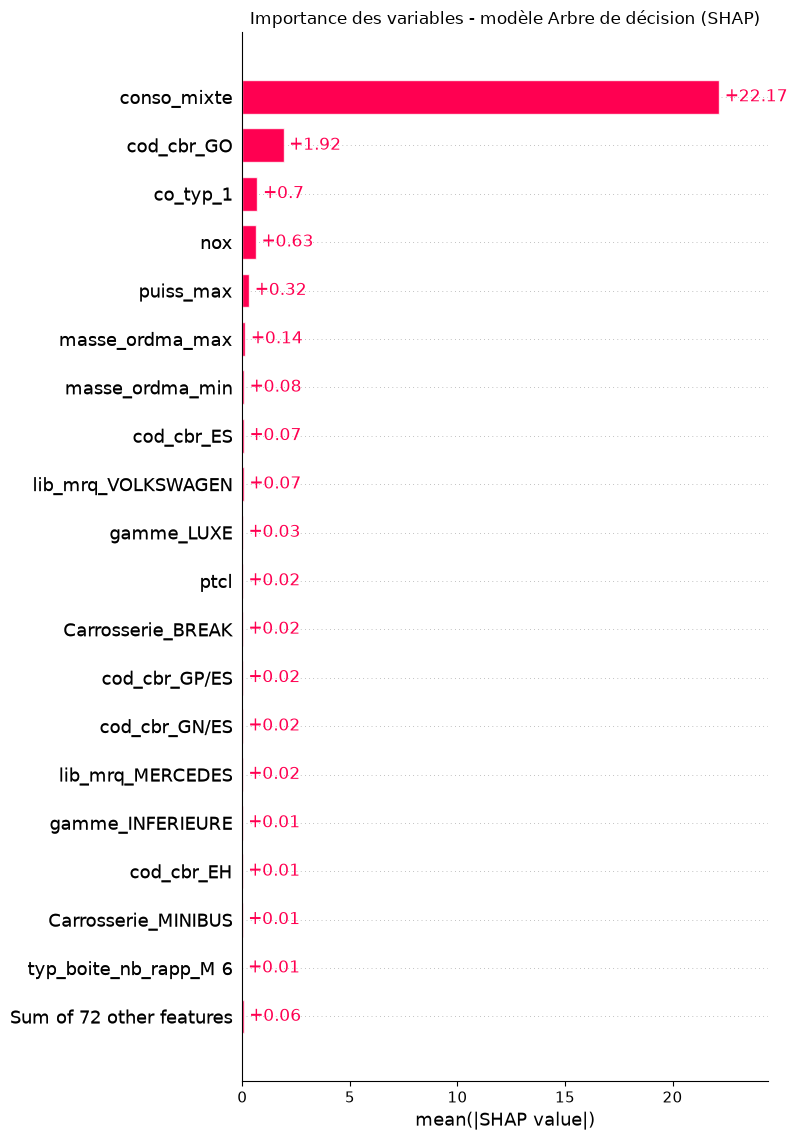

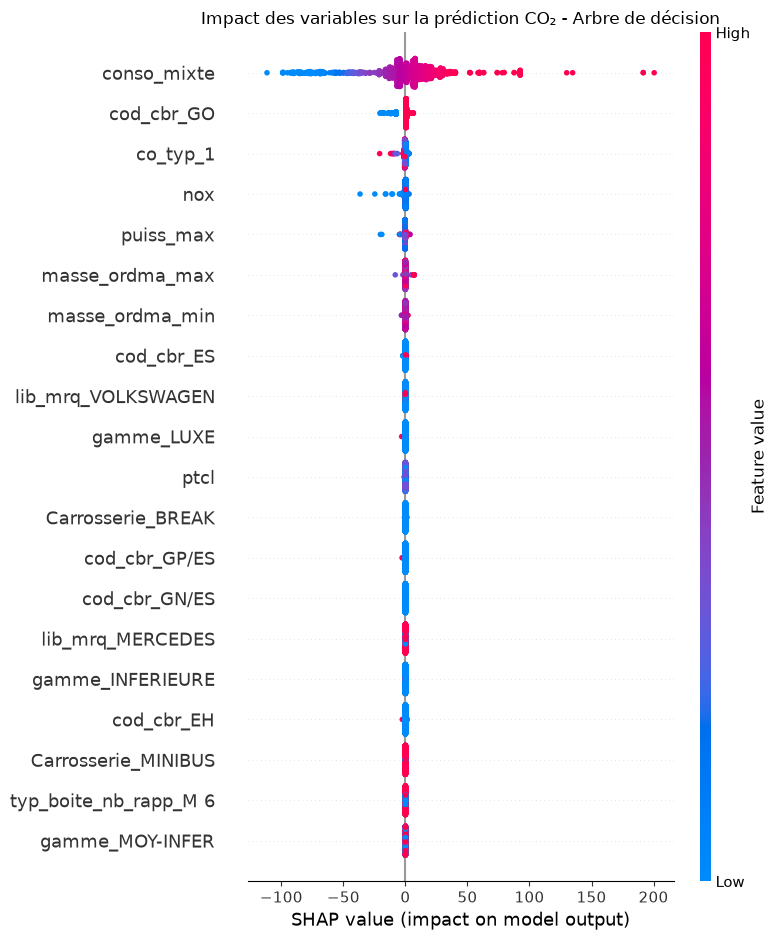

Explication de la prédiction de l'observation : 59
Index d'origine : 18137


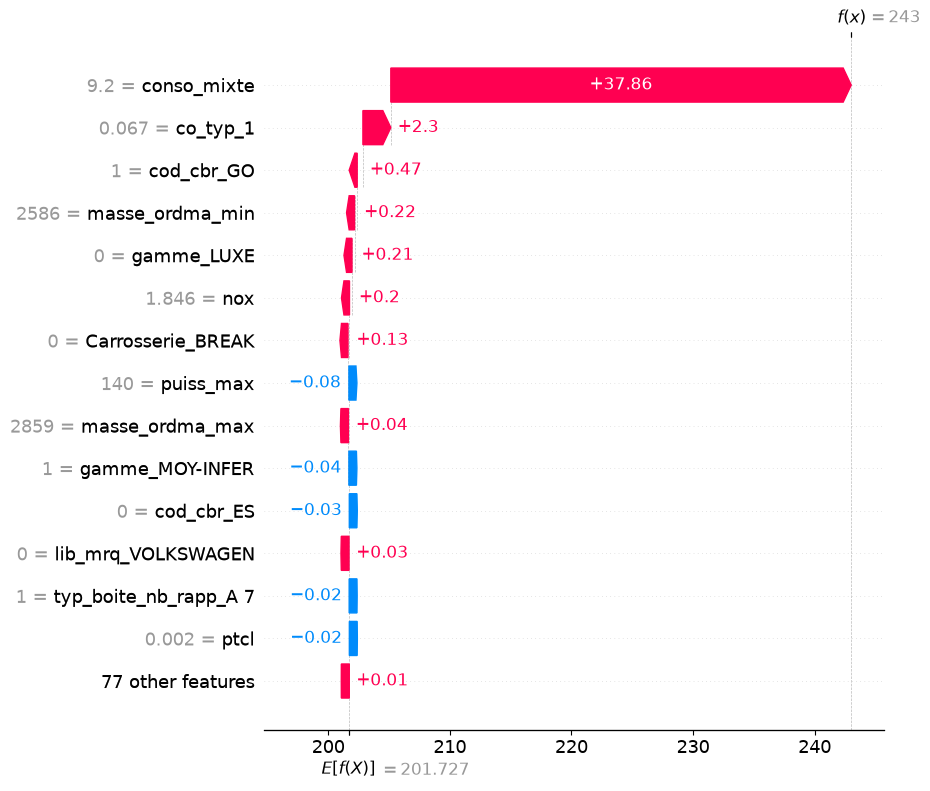

In [47]:
# ==========================================================
# SHAP - Arbre de décision
# ==========================================================

# ----------------------------------------------------------
# 1) Échantillon pour l'analyse SHAP
# ----------------------------------------------------------

X_train_sample = X_train.sample(
    1000,
    random_state=42
)

# ----------------------------------------------------------
# 2) Création de l'explainer SHAP
# ----------------------------------------------------------

explainer = shap.TreeExplainer(
    tree
)

# ----------------------------------------------------------
# 3) Calcul des valeurs SHAP
# ----------------------------------------------------------

shap_values = explainer(
    X_train_sample
)

print(
    "Dimension des valeurs SHAP :",
    shap_values.values.shape
)

# ==========================================================
# GRAPHIQUE 1 : IMPORTANCE GLOBALE DES VARIABLES
# ==========================================================

plt.figure(figsize=(10, 8))

display(
    pd.DataFrame(
        {
            "Variable": X_train_sample.columns,
            "SHAP": shap_values.values[59]
        }
    )
    .sort_values(
        "SHAP",
        key=abs,
        ascending=False
    )
)

print(
    "Observation analysée :",
    59
)

print(
    "Index d'origine :",
    X_train_sample.index[59]
)

shap.plots.bar(
    shap_values,
    max_display=20,
    show=False
)

plt.title(
    "Importance des variables - modèle Arbre de décision (SHAP)"
)

plt.tight_layout()

plt.show()

# ==========================================================
# GRAPHIQUE 2 : IMPACT DES VARIABLES SUR LE CO₂
# ==========================================================

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values.values,
    X_train_sample,
    max_display=20,
    show=False
)

plt.title(
    "Impact des variables sur la prédiction CO₂ - Arbre de décision"
)

plt.tight_layout()

plt.show()

# ==========================================================
# GRAPHIQUE 3 : EXPLICATION D'UNE PRÉDICTION INDIVIDUELLE
# ==========================================================

index = 59

print(
    "Explication de la prédiction de l'observation :",
    index
)

print(
    "Index d'origine :",
    X_train_sample.index[index]
)

shap.plots.waterfall(
    shap_values[index],
    max_display=15
)

### Interprétation des résultats

L'analyse SHAP du modèle Arbre de décision montre que la consommation mixte (conso_mixte) reste, de très loin, la variable la plus influente dans les prédictions des émissions de CO₂. Son importance est largement supérieure à celle des autres variables, ce qui confirme les observations réalisées avec les modèles précédents.

Contrairement au modèle Lasso, l'Arbre de décision conserve toutefois un plus grand nombre de variables dans son processus de décision. Des variables telles que cod_cbr_GO, co_typ_1, nox, puiss_max, masse_ordma_max et masse_ordma_min participent également aux prédictions, même si leur contribution demeure nettement inférieure à celle de conso_mixte.

Le graphique de synthèse montre que les valeurs élevées de conso_mixte augmentent fortement les émissions de CO₂ prédites, tandis que les autres variables exercent des effets plus localisés selon les caractéristiques des véhicules. Cette répartition illustre la capacité de l'Arbre de décision à modéliser des relations non linéaires entre les variables explicatives et la variable cible.

L'explication individuelle confirme ce fonctionnement. Pour l'observation étudiée, la prédiction est principalement déterminée par conso_mixte, complétée par les contributions de co_typ_1, cod_cbr_GO et de quelques variables techniques. Le modèle combine ainsi plusieurs règles de décision successives afin d'aboutir à la prédiction finale.

Dans l'ensemble, cette analyse met en évidence la capacité de l'Arbre de décision à exploiter simultanément plusieurs variables tout en conservant une excellente interprétabilité. Les résultats sont cohérents avec les performances obtenues lors de l'évaluation du modèle, qui présente les meilleures métriques de cette étude. Ils confirment également que la très forte influence de conso_mixte explique en grande partie les excellentes performances observées, ce qui justifie les expérimentations réalisées dans le notebook d'expérience après suppression des variables les plus fortement corrélées à la cible.

## Synthèse des analyses SHAP

L'analyse d'interprétabilité réalisée à l'aide de SHAP confirme les enseignements obtenus lors de l'analyse exploratoire et de l'évaluation des modèles.

Quel que soit le modèle étudié, la consommation mixte (conso_mixte) apparaît systématiquement comme la variable la plus influente dans la prédiction des émissions de CO₂. Son impact est largement supérieur à celui des autres variables, ce qui traduit la très forte relation existant entre cette variable et la cible.

Les modèles Régression linéaire et Ridge présentent des comportements très proches. Les mêmes variables expliquent les prédictions avec des niveaux d'importance quasiment identiques, ce qui confirme que la régularisation L2 n'a qu'un impact limité sur l'interprétation du modèle.

À l'inverse, le modèle Lasso sélectionne automatiquement un nombre plus restreint de variables. Les prédictions reposent principalement sur quelques variables essentielles, illustrant le rôle de la pénalisation L1 dans la simplification du modèle.

Enfin, l'Arbre de décision conserve davantage de variables dans son processus de décision et met en évidence des relations non linéaires entre les caractéristiques des véhicules et les émissions de CO₂. Malgré cette complexité supplémentaire, conso_mixte demeure la variable dominante.

Dans l'ensemble, les analyses SHAP mettent en évidence une forte cohérence entre les différents modèles étudiés. Elles confirment que les excellentes performances obtenues reposent principalement sur la présence de variables très fortement corrélées à la cible, en particulier conso_mixte. Ce constat justifie pleinement les expérimentations complémentaires réalisées dans le notebook d'expérience, visant à évaluer les performances des modèles après suppression des variables les plus corrélées afin de vérifier leur capacité réelle de généralisation.